# Forecasting COVID-19 Cases and Deaths in Germany
## A Time Series Analysis of RKI Notification Data

**Authors:** Ajeyaa Sinha Roy, Danish Ahmad, Tom Schwaiger, Julia Wingenfeld  
**Course:** Case Studies, Summer Semester 2026  
**Lecturers:** Prof. Dr. Matei Demetrescu, Dr. Paul Navas

---

This notebook implements and evaluates autoregressive models for one-step-ahead forecasting of daily COVID-19 cases and deaths in Germany using RKI notification data (March 2020 – April 2026). The analysis proceeds in six parts:

1. **Part (a):** Data loading, aggregation, log transformation, and exploratory plots
2. **Part (b):** AR order selection via AIC/BIC
3. **Part (c):** In-sample evaluation of AR(1), AR(7), AR(p_BIC)
4. **Part (d):** Extended AR(7) with exogenous regressors (age composition, temperature, regime indicator)
5. **Part (e):** Seasonal ARIMA extensions and stationarity/spectral diagnostics
6. **Part (f):** Complete rolling-window out-of-sample evaluation with Diebold–Mariano tests

Data Loaded! Rows: 2193
Check: Max cases in data: 307836
Date range: 2020-03-31  ->  2026-04-01
N observations: 2,193
Total cases : 39,124,496
Total deaths: 187,277


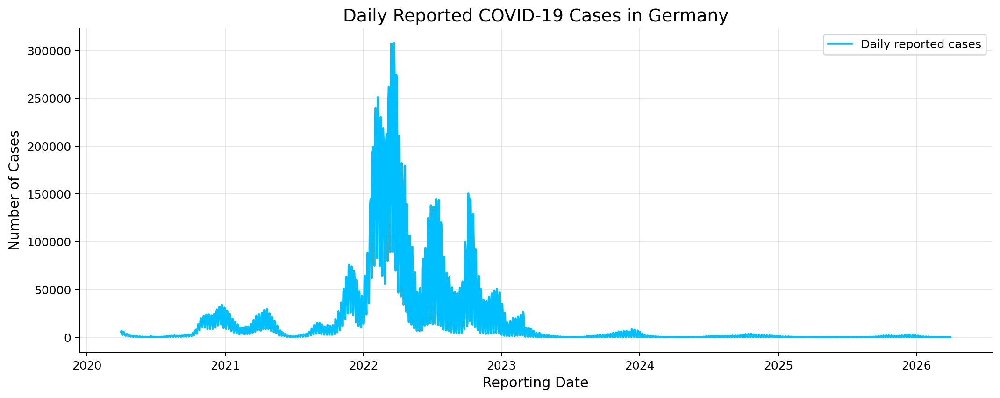

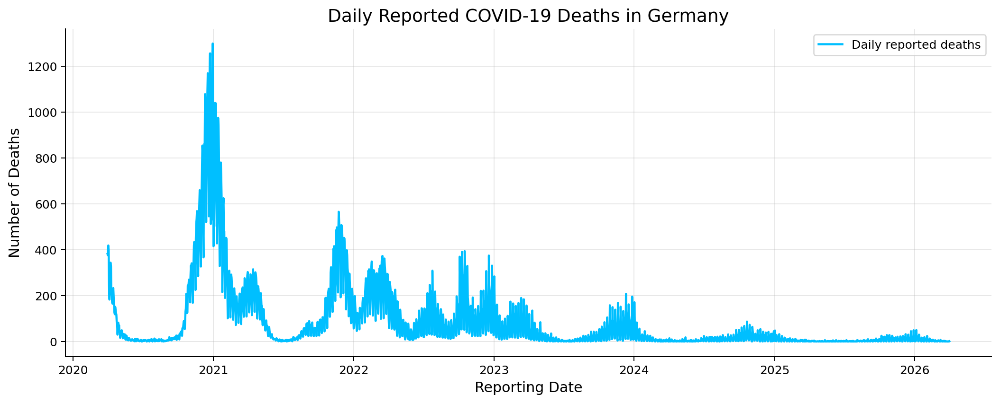

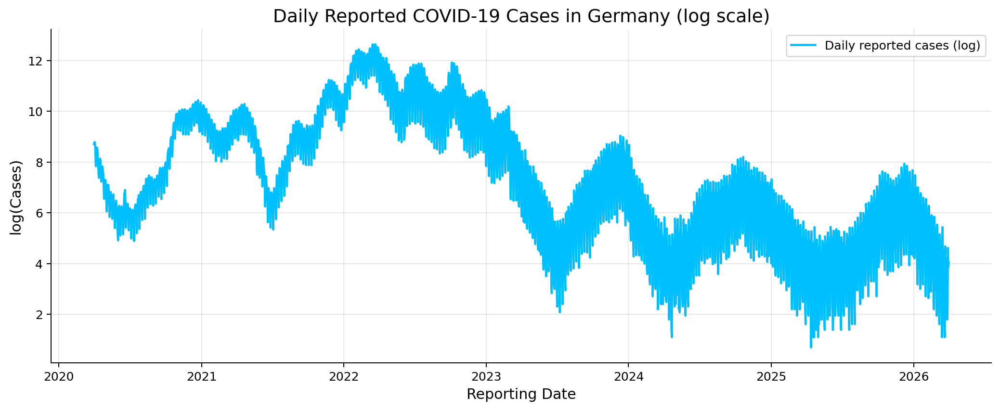

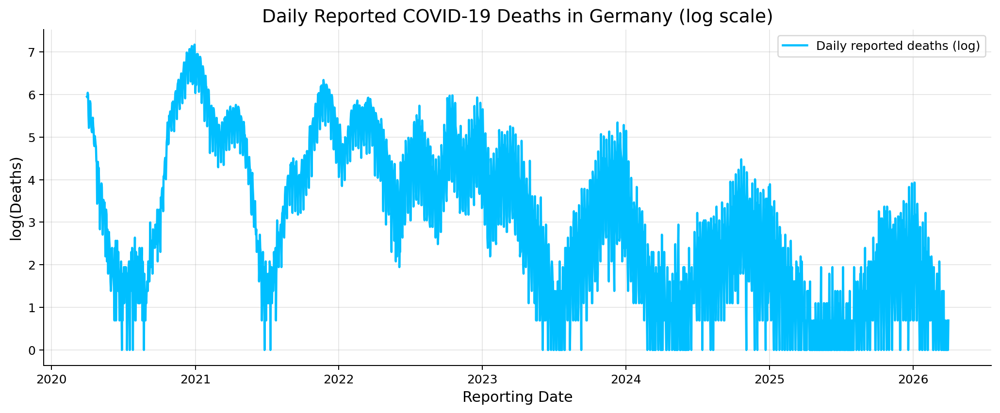

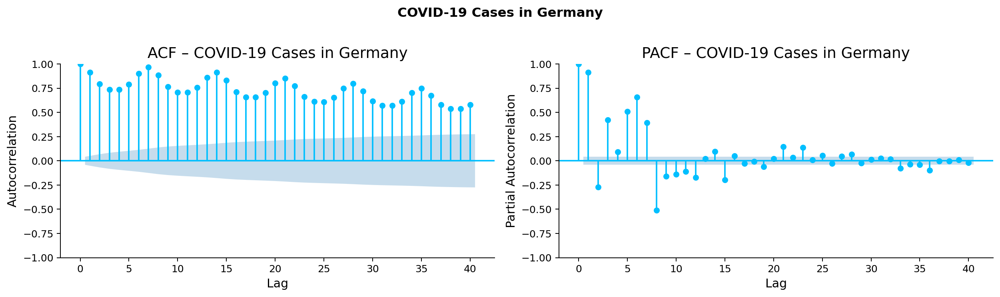

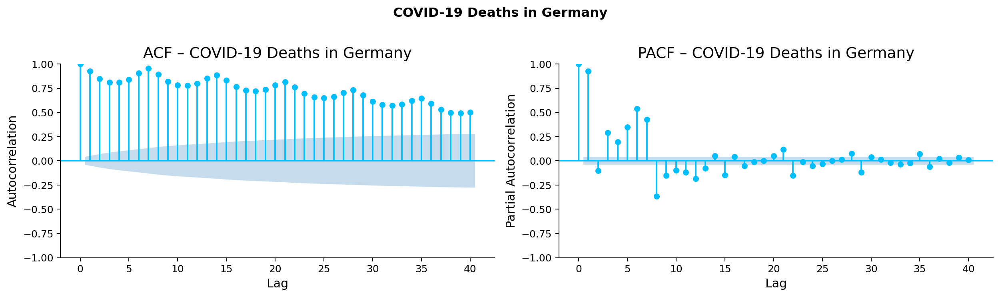

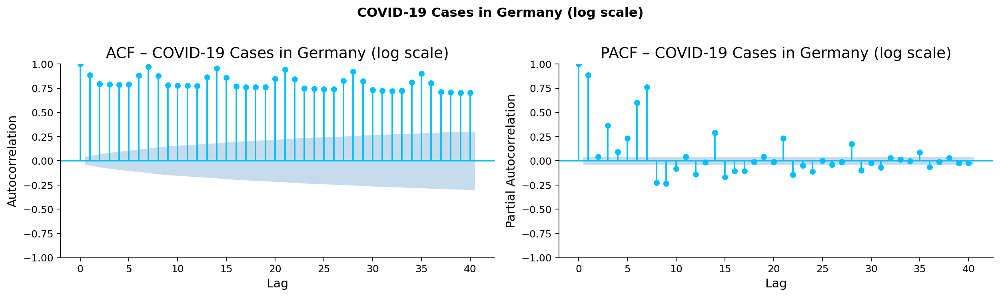

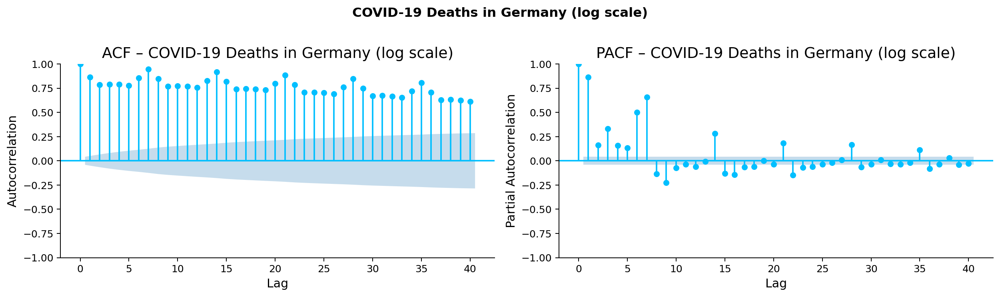

In [1]:
# ============================================================
# PART (a) — Load, aggregate, log-transform, plot
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import requests
from io import BytesIO


# 1. Load data from web (Exactly like your first notebook)
headers = {"Accept": "application/vnd.git-lfs+json"}
url = "https://media.githubusercontent.com/media/robert-koch-institut/SARS-CoV-2-Infektionen_in_Deutschland/main/Aktuell_Deutschland_SarsCov2_Infektionen.csv"

# Note: If you get ModuleNotFoundError, run: !pip install requests
response = requests.get(url, headers=headers)
df = pd.read_csv(BytesIO(response.content), encoding='utf-8-sig', parse_dates=["Meldedatum"])

# 2. Aggregate to daily totals
# Ensure we drop timezone info if any, for statsmodels compatibility
df["Meldedatum"] = df["Meldedatum"].dt.tz_localize(None)
df_grouped = df.groupby("Meldedatum")[["AnzahlFall", "AnzahlTodesfall"]].sum()

# 3. Reindex
min_date = "2020-03-31"
max_date = "2026-04-01"
date_idx = pd.date_range(min_date, max_date)
df_grouped_filled = df_grouped.reindex(date_idx, fill_value=0)
df_grouped_filled.index.name = "Meldedatum"

# 4. Log-transform (Restoring your specific original names)
df_grouped_filled["logAnzahlFall"]      = np.log1p(df_grouped_filled["AnzahlFall"])
df_grouped_filled["logAnzahlTodesfall"] = np.log1p(df_grouped_filled["AnzahlTodesfall"])

# This ensures subsequent cells (Parts b, c, d, e) find the expected variables
data_full = df_grouped_filled 

print(f"Data Loaded! Rows: {len(df_grouped_filled)}")
print(f"Check: Max cases in data: {df_grouped_filled['AnzahlFall'].max()}")

print(f"Date range: {df_grouped_filled.index.min().date()}  ->  {df_grouped_filled.index.max().date()}")
print(f"N observations: {len(df_grouped_filled):,}")
print(f"Total cases : {int(df_grouped_filled['AnzahlFall'].sum()):,}")
print(f"Total deaths: {int(df_grouped_filled['AnzahlTodesfall'].sum()):,}")

# ---- Plotting ----
plot_df = df_grouped_filled.copy().reset_index()
plot_df = plot_df.sort_values("Meldedatum")
x = plot_df["Meldedatum"]

plt.rcParams.update({
    "figure.figsize":  (14, 5),
    "figure.dpi":      180,
    "axes.titlesize":  15,
    "axes.labelsize":  12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

series_configs = [
    {"y_col": "AnzahlFall",         "title": "Daily Reported COVID-19 Cases in Germany",
     "ylabel": "Number of Cases",   "label": "Daily reported cases"},
    {"y_col": "AnzahlTodesfall",    "title": "Daily Reported COVID-19 Deaths in Germany",
     "ylabel": "Number of Deaths",  "label": "Daily reported deaths"},
    {"y_col": "logAnzahlFall",      "title": "Daily Reported COVID-19 Cases in Germany (log scale)",
     "ylabel": "log(Cases)",        "label": "Daily reported cases (log)"},
    {"y_col": "logAnzahlTodesfall", "title": "Daily Reported COVID-19 Deaths in Germany (log scale)",
     "ylabel": "log(Deaths)",       "label": "Daily reported deaths (log)"},
]
for cfg in series_configs:
    locator   = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    fig, ax = plt.subplots(dpi=180)
    ax.plot(x, plot_df[cfg["y_col"]], color="deepskyblue", linewidth=1.8, label=cfg["label"])
    ax.set_title(cfg["title"]); ax.set_xlabel("Reporting Date"); ax.set_ylabel(cfg["ylabel"])
    ax.grid(True, alpha=0.3); ax.legend(loc="upper right")
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.show()

acf_configs = [
    {"y_col": "AnzahlFall",         "title": "COVID-19 Cases in Germany"},
    {"y_col": "AnzahlTodesfall",    "title": "COVID-19 Deaths in Germany"},
    {"y_col": "logAnzahlFall",      "title": "COVID-19 Cases in Germany (log scale)"},
    {"y_col": "logAnzahlTodesfall", "title": "COVID-19 Deaths in Germany (log scale)"},
]
for cfg in acf_configs:
    series = plot_df[cfg["y_col"]].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=180)
    plot_acf(series, lags=40, ax=axes[0], color="deepskyblue",
             vlines_kwargs={"colors": "deepskyblue"}, alpha=0.05)
    axes[0].set_title(f"ACF – {cfg['title']}")
    axes[0].set_xlabel("Lag"); axes[0].set_ylabel("Autocorrelation")
    axes[0].spines["top"].set_visible(False); axes[0].spines["right"].set_visible(False)
    plot_pacf(series, lags=40, ax=axes[1], method="ywm", color="deepskyblue",
              vlines_kwargs={"colors": "deepskyblue"}, alpha=0.05)
    axes[1].set_title(f"PACF – {cfg['title']}")
    axes[1].set_xlabel("Lag"); axes[1].set_ylabel("Partial Autocorrelation")
    axes[1].spines["top"].set_visible(False); axes[1].spines["right"].set_visible(False)
    plt.suptitle(cfg["title"], fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout(); plt.show()

## Part (a) — Summary Statistics

We compute descriptive statistics for the raw and log-transformed daily case and death series. The raw counts are heavily right-skewed (mean >> median), with extreme peaks during major pandemic waves. The log transformation compresses this variation onto a more moderate scale suitable for linear modelling.

In [2]:
# ============================================================
# Summary statistics for raw and log-transformed daily series
# ============================================================

summary_stats = data_full[
    ["AnzahlFall", "AnzahlTodesfall", "logAnzahlFall", "logAnzahlTodesfall"]
].describe().T

summary_stats = summary_stats[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
]

summary_stats = summary_stats.rename(index={
    "AnzahlFall": "Cases",
    "AnzahlTodesfall": "Deaths",
    "logAnzahlFall": "Log cases",
    "logAnzahlTodesfall": "Log deaths"
})

summary_stats = summary_stats.round(2)

summary_stats

,count,mean,std,min,25%,50%,75%,max
Cases,2193.0,17840.63,41928.59,1.00,260.00,1455.00,12640.00,307836.00
Deaths,2193.0,85.40,156.54,0.00,4.00,18.00,97.00,1300.00
Log cases,2193.0,7.41,2.56,0.69,5.56,7.28,9.44,12.64
Log deaths,2193.0,3.04,1.86,0.00,1.61,2.94,4.58,7.17


## Part (a) — Data Quality Checks

Before modelling, we verify the integrity of the raw RKI data:
- Inspect `NeuerFall` / `NeuerTodesfall` / `NeuGenesen` status flags (not used directly in forecasting)
- Check for exact duplicate rows (none found)
- Identify negative values in `AnzahlFall` (4 entries — retrospective corrections by health authorities)
- Confirm no calendar gaps in the daily series

In [3]:
# ============================================================
# PART (a) — Data Quality Checks
# Output supports the writeup for:
#   (i)  why we drop NeuerFall / NeuerTodesfall / NeuGenesen
#   (ii) absence of negative counts
#   (iii) absence of exact duplicates
#   (iv) calendar coverage under fill_value=0
# ============================================================

print("=" * 60)
print("1. 'Neu'-column flag distributions")
print("=" * 60)
for col in ["NeuerFall", "NeuerTodesfall", "NeuGenesen"]:
    vc = df[col].value_counts().sort_index()
    print(f"\n{col}:")
    print(vc.to_string())

# Interpretation: these are status flags (-9 = not yet in current snapshot,
# 0 = present in this snapshot AND in the previous, 1 = newly added,
# -1 = removed). They drive the "Neu*" running counters, NOT the count
# itself. Since we sum AnzahlFall / AnzahlTodesfall over all rows for a
# given Meldedatum, the flag value is irrelevant to the aggregate — every
# case row contributes once. We therefore drop these columns.

# Cross-check: rows with NeuerTodesfall == -9 (not in current snapshot)
# should still carry valid AnzahlTodesfall values.
print("\nAnzahlTodesfall distribution when NeuerTodesfall == -9:")
print(df.loc[df["NeuerTodesfall"] == -9, "AnzahlTodesfall"].value_counts().to_string())

print("\n" + "=" * 60)
print("2. Negative counts in the count columns")
print("=" * 60)
n_neg_cases  = (df["AnzahlFall"]      < 0).sum()
n_neg_deaths = (df["AnzahlTodesfall"] < 0).sum()
print(f"  AnzahlFall      < 0 : {n_neg_cases:>6d} rows")
print(f"  AnzahlTodesfall < 0 : {n_neg_deaths:>6d} rows")
# Expectation: zero. Negatives would indicate revision artefacts.

print("\n" + "=" * 60)
print("3. Exact duplicate rows in the raw register")
print("=" * 60)
print(f"  Duplicate rows: {df.duplicated().sum()}")

print("\n" + "=" * 60)
print("4. Calendar coverage (justifies fill_value=0)")
print("=" * 60)
gaps_mask = df_grouped.reindex(date_idx).isna().any(axis=1)
n_gaps = int(gaps_mask.sum())
print(f"  Modeling window:   {date_idx.min().date()}  ->  {date_idx.max().date()}")
print(f"  Total days:        {len(date_idx):,}")
print(f"  Days with no RKI row: {n_gaps}")
if n_gaps > 0:
    print(f"  Example gap dates: {list(gaps_mask[gaps_mask].index[:5].date)}")
    print(f"  --> fill_value=0 imposes log1p(0)=0 on {n_gaps} day(s).")
else:
    print(f"  --> fill_value=0 is equivalent to fill_value=NaN here "
          f"(no gaps to fill).")

1. 'Neu'-column flag distributions

NeuerFall:
NeuerFall
0    7754873
1          1

NeuerTodesfall:
NeuerTodesfall
-9    7587467
 0     167407

NeuGenesen:
NeuGenesen
-9     167752
 0    7587081
 1         41

AnzahlTodesfall distribution when NeuerTodesfall == -9:
AnzahlTodesfall
0    7587467

2. Negative counts in the count columns
  AnzahlFall      < 0 :      0 rows
  AnzahlTodesfall < 0 :      0 rows

3. Exact duplicate rows in the raw register
  Duplicate rows: 0

4. Calendar coverage (justifies fill_value=0)
  Modeling window:   2020-03-31  ->  2026-04-01
  Total days:        2,193
  Days with no RKI row: 0
  --> fill_value=0 is equivalent to fill_value=NaN here (no gaps to fill).


## Part (b) — AR(p) Order Selection

We estimate consecutive AR(p) models by OLS for $p = 1, \ldots, 365$ and select the lag order by minimising the BIC. The AIC is also computed for comparison, and `statsmodels`' `ar_select_order` is used as a robustness check.

**Expected results:**
- BIC minimum at $p = 50$ for cases and $p = 36$ for deaths
- AIC selects much longer orders ($p = 365$ for cases, $p = 210$ for deaths)
- Both criteria drop sharply over the first ~7 lags, confirming the weekly reporting cycle

Cases: AIC picks p = 365,  BIC picks p = 49
Deaths: AIC picks p = 59,  BIC picks p = 28

=== Cases (log) ===
AIC minimum at p = 365  (AIC = 2122.6)
BIC minimum at p = 50  (BIC = 2592.7)


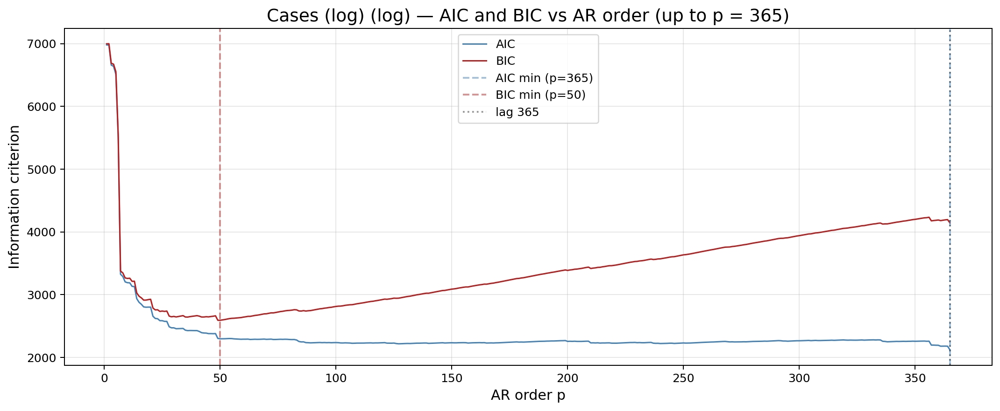


=== Deaths (log) ===
AIC minimum at p = 210  (AIC = 2512.2)
BIC minimum at p = 36  (BIC = 2960.3)


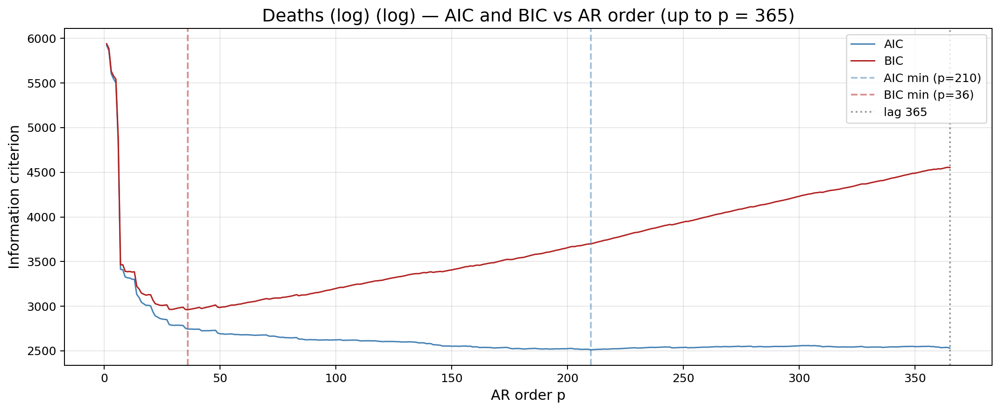

In [4]:
# ============================================================
# PART (b) — AR(p) order selection on log series
# ============================================================
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

y_cases  = df_grouped_filled["logAnzahlFall"].dropna()
y_deaths = df_grouped_filled["logAnzahlTodesfall"].dropna()

MAX_LAG = 365

# ---- ar_select_order: returns the highest selected lag in the chosen model ----
# (may pick a non-consecutive lag set, so this can differ from the curve minimum)
for name, s in [("Cases", y_cases), ("Deaths", y_deaths)]:
    p_aic = ar_select_order(s, maxlag=MAX_LAG, ic="aic", trend="c").ar_lags[-1]
    p_bic = ar_select_order(s, maxlag=MAX_LAG, ic="bic", trend="c").ar_lags[-1]
    print(f"{name}: AIC picks p = {p_aic},  BIC picks p = {p_bic}")


# ---- Full AIC/BIC curve over consecutive AR(p) ----
def aic_bic_curve(series, name, max_lag=MAX_LAG):
    lags_tried = list(range(1, max_lag + 1))
    aics, bics = [], []
    for p in lags_tried:
        fit = AutoReg(series, lags=p, trend="c", old_names=False).fit()
        aics.append(fit.aic); bics.append(fit.bic)
    aics, bics = np.array(aics), np.array(bics)
    p_aic_min = lags_tried[np.argmin(aics)]
    p_bic_min = lags_tried[np.argmin(bics)]
    print(f"\n=== {name} ===")
    print(f"AIC minimum at p = {p_aic_min}  (AIC = {aics.min():.1f})")
    print(f"BIC minimum at p = {p_bic_min}  (BIC = {bics.min():.1f})")

    fig, ax = plt.subplots(figsize=(12, 5), dpi=180)
    ax.plot(lags_tried, aics, lw=1.2, label="AIC", color="steelblue")
    ax.plot(lags_tried, bics, lw=1.2, label="BIC", color="firebrick")
    ax.axvline(p_aic_min, color="steelblue", ls="--", alpha=0.5,
               label=f"AIC min (p={p_aic_min})")
    ax.axvline(p_bic_min, color="firebrick", ls="--", alpha=0.5,
               label=f"BIC min (p={p_bic_min})")
    ax.axvline(365, color="black", ls=":", alpha=0.4, label="lag 365")
    ax.set_xlabel("AR order p"); ax.set_ylabel("Information criterion")
    ax.set_title(f"{name} (log) — AIC and BIC vs AR order (up to p = {max_lag})")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

aic_bic_curve(y_cases,  "Cases (log)")
aic_bic_curve(y_deaths, "Deaths (log)")

## Part (c) — In-Sample AR(1) vs AR(7) vs AR(p_BIC)

We estimate and compare the three pure autoregressive specifications in-sample. For each model, we compute AIC, BIC, and the MSFE on the log scale. Fitted values and residual ACFs are plotted to assess model adequacy.

**Key findings:**
- AR(1) → AR(7): MSFE drops by ~56% for cases and ~43% for deaths — the weekly reporting cycle is the dominant source of predictability
- AR(7) → AR(p_BIC): further gains of ~22% for cases and ~15% for deaths
- Residual ACFs for BIC-selected models are approximately white noise
- Theil's $U < 1$ for all models beyond AR(1), confirming they outperform the naïve random-walk benchmark

Model                                  AIC         BIC         MSFE(log)
---------------------------------------------------------------------------
Cases  — AR(1)                  AIC=  6981.1   BIC=  6998.2   MSFE(log)= 1.1878
Cases  — AR(7)                  AIC=  3326.6   BIC=  3377.8   MSFE(log)= 0.5157
Cases  — AR(50)                 AIC=  2297.9   BIC=  2592.7   MSFE(log)= 0.4037
Deaths — AR(1)                  AIC=  5922.6   BIC=  5939.7   MSFE(log)= 0.9330
Deaths — AR(7)                  AIC=  3412.7   BIC=  3463.9   MSFE(log)= 0.5260
Deaths — AR(36)                 AIC=  2744.6   BIC=  2960.3   MSFE(log)= 0.4492


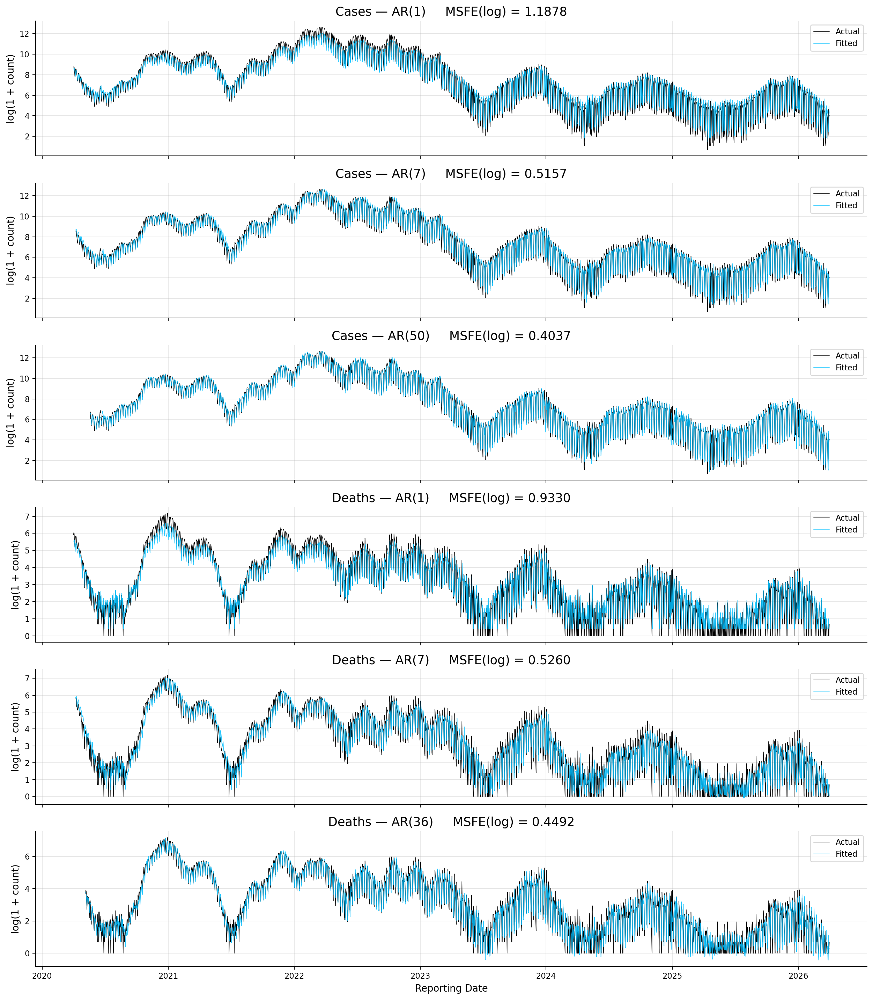

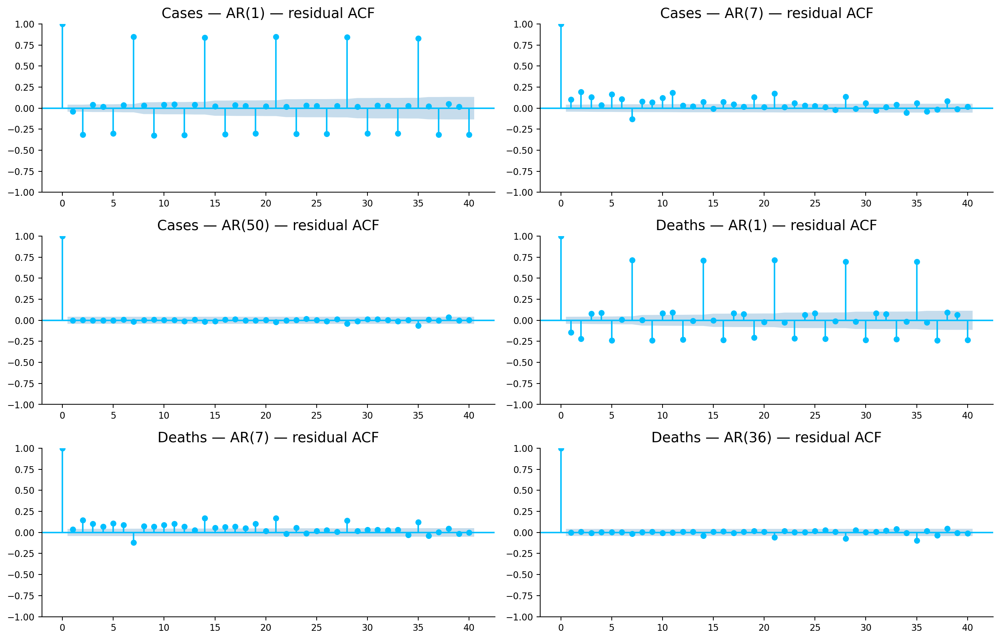

=== Theil's U (log scale, naive = y_log_{t-1}) ===
Cases  AR(7):   U = 0.421   (model RMSE = 0.5157, naive RMSE = 1.2247)
Deaths AR(7):   U = 0.544   (model RMSE = 0.5260, naive RMSE = 0.9677)


In [5]:
# ============================================================
# PART (c) — AR(1) vs AR(7) vs BIC-selected AR  (log scale)
# ============================================================
from statsmodels.graphics.tsaplots import plot_acf

# BIC-selected nonseasonal orders from Part (b) curve minima
P_BIC_CASES_C  = 50
P_BIC_DEATHS_C = 36

def fit_and_eval(y_log, p, label):
    """In-sample one-step-ahead AR(p) fit on log series, MSFE on log scale."""
    fit = AutoReg(y_log, lags=p, trend="c", old_names=False).fit()
    y_log_hat = fit.predict(start=p, end=len(y_log) - 1)
    y_log_hat.index = y_log.index[p:]
    y_log_act = y_log.loc[y_log_hat.index]
    msfe_log  = np.sqrt(((y_log_act - y_log_hat) ** 2).mean())
    print(f"{label:30s}  AIC={fit.aic:8.1f}   BIC={fit.bic:8.1f}   "
          f"MSFE(log)={msfe_log:7.4f}")
    return fit, y_log_act, y_log_hat, msfe_log


print(f"{'Model':30s}  {'AIC':>10s}  {'BIC':>10s}   {'MSFE(log)':>15s}")
print("-" * 75)

fit_c1,  yLc_a_1,  yLc_h_1,  ml_c1   = fit_and_eval(y_cases, 1,                "Cases  — AR(1)")
fit_c7,  yLc_a_7,  yLc_h_7,  ml_c7   = fit_and_eval(y_cases, 7,                "Cases  — AR(7)")
fit_c50, yLc_a_50, yLc_h_50, ml_c50  = fit_and_eval(y_cases, P_BIC_CASES_C,    f"Cases  — AR({P_BIC_CASES_C})")

fit_d1,  yLd_a_1,  yLd_h_1,  ml_d1   = fit_and_eval(y_deaths, 1,               "Deaths — AR(1)")
fit_d7,  yLd_a_7,  yLd_h_7,  ml_d7   = fit_and_eval(y_deaths, 7,               "Deaths — AR(7)")
fit_d36, yLd_a_36, yLd_h_36, ml_d36  = fit_and_eval(y_deaths, P_BIC_DEATHS_C,  f"Deaths — AR({P_BIC_DEATHS_C})")


# ============================================================
# Fitted vs actual — log scale only
# ============================================================
plt.rcParams.update({
    "figure.dpi": 180, "axes.titlesize": 14, "axes.labelsize": 11,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
})
log_panels = [
    (f"Cases — AR(1)",                  yLc_a_1,  yLc_h_1,  ml_c1),
    (f"Cases — AR(7)",                  yLc_a_7,  yLc_h_7,  ml_c7),
    (f"Cases — AR({P_BIC_CASES_C})",    yLc_a_50, yLc_h_50, ml_c50),
    (f"Deaths — AR(1)",                 yLd_a_1,  yLd_h_1,  ml_d1),
    (f"Deaths — AR(7)",                 yLd_a_7,  yLd_h_7,  ml_d7),
    (f"Deaths — AR({P_BIC_DEATHS_C})",  yLd_a_36, yLd_h_36, ml_d36),
]
fig, axes = plt.subplots(6, 1, figsize=(14, 16), sharex=True)
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
for ax, (title, y_act, y_hat, msfe) in zip(axes, log_panels):
    ax.plot(y_act.index, y_act.values, lw=0.6, color="black",      label="Actual")
    ax.plot(y_hat.index, y_hat.values, lw=0.6, color="deepskyblue", alpha=0.85, label="Fitted")
    ax.set_title(f"{title}     MSFE(log) = {msfe:.4f}")
    ax.set_ylabel("log(1 + count)"); ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
axes[-1].set_xlabel("Reporting Date")
plt.tight_layout(); plt.show()


# ============================================================
# Residual ACFs
# ============================================================
resid_panels = [
    (f"Cases — AR(1)",                  fit_c1.resid),
    (f"Cases — AR(7)",                  fit_c7.resid),
    (f"Cases — AR({P_BIC_CASES_C})",    fit_c50.resid),
    (f"Deaths — AR(1)",                 fit_d1.resid),
    (f"Deaths — AR(7)",                 fit_d7.resid),
    (f"Deaths — AR({P_BIC_DEATHS_C})",  fit_d36.resid),
]
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, (title, resid) in zip(axes.flat, resid_panels):
    plot_acf(resid.dropna(), lags=40, ax=ax, color="deepskyblue",
             vlines_kwargs={"colors": "deepskyblue"}, alpha=0.05)
    ax.set_title(f"{title} — residual ACF")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


# ============================================================
# Theil's U — log scale (naive = y_log_{t-1})
# ============================================================
def theils_u_log(y_log_act, y_log_hat, y_log_full):
    """Theil's U on log scale: model RMSE / naive RMSE,
       where the naive forecast is the previous log value."""
    y_log_naive = y_log_full.shift(1).loc[y_log_hat.index]
    common = y_log_naive.dropna().index
    y_a, y_h, y_n = y_log_act.loc[common], y_log_hat.loc[common], y_log_naive.loc[common]
    rmse_model = np.sqrt(((y_a - y_h) ** 2).mean())
    rmse_naive = np.sqrt(((y_a - y_n) ** 2).mean())
    return rmse_model / rmse_naive, rmse_model, rmse_naive


u_c, rmse_c_m, rmse_c_n = theils_u_log(yLc_a_7, yLc_h_7, y_cases)
u_d, rmse_d_m, rmse_d_n = theils_u_log(yLd_a_7, yLd_h_7, y_deaths)
print("=== Theil's U (log scale, naive = y_log_{t-1}) ===")
print(f"Cases  AR(7):   U = {u_c:.3f}   "
      f"(model RMSE = {rmse_c_m:.4f}, naive RMSE = {rmse_c_n:.4f})")
print(f"Deaths AR(7):   U = {u_d:.3f}   "
      f"(model RMSE = {rmse_d_m:.4f}, naive RMSE = {rmse_d_n:.4f})")

## Part (d.1) — Load Temperature and Build Feature Matrix

We prepare the exogenous regressors for the extended AR(7) models:
- **Temperature:** daily mean for Germany's centroid (51.17°N, 10.45°E) from the Open-Meteo Historical Weather API
- **Age-stratified cases:** daily case counts for the six RKI age groups (A00–A04, A05–A14, A15–A34, A35–A59, A60–A79, A80+), log-transformed
- **Regime indicator:** binary variable (= 1 from April 2023 onward) capturing the documented decline in surveillance sensitivity after the end of free Bürgertests

In [6]:
# ============================================================
# PART (d.1) — Load temperature + build age panel + feature matrix
# ============================================================

# 1. Temperature from Open-Meteo (Germany centroid)
lat, lon = 51.1657, 10.4515
weather_url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={min_date}&end_date={max_date}"
    f"&daily=temperature_2m_mean&timezone=GMT"
)

try:
    response = requests.get(weather_url)
    weather_data = response.json()
    daily_mean_pd = pd.DataFrame({
        "Meldedatum":       pd.to_datetime(weather_data["daily"]["time"]),
        "temp_mean_germany": weather_data["daily"]["temperature_2m_mean"],
    })
    daily_mean_pd["Meldedatum"] = daily_mean_pd["Meldedatum"].dt.tz_localize(None)
    temp_map = daily_mean_pd.set_index("Meldedatum")["temp_mean_germany"]
    temp = df_grouped_filled.index.map(temp_map)
    print("Weather data loaded.")
except Exception as e:
    print(f"Error fetching weather data: {e}")
    temp = None

# 2. Age-specific case counts (panel pivoted to wide form)
panel = df.groupby(["Meldedatum", "Altersgruppe"])["AnzahlFall"].sum().reset_index()
cases_by_age = (
    panel.pivot(index="Meldedatum", columns="Altersgruppe", values="AnzahlFall")
         .fillna(0)
         .reindex(df_grouped_filled.index, fill_value=0)
)
cases_by_age.columns = [
    f"cases_{str(c).replace('-', '_').replace('+', 'plus')}"
    for c in cases_by_age.columns
]
print("Age columns:", cases_by_age.columns.tolist())

# 3. Full feature matrix
data_full = df_grouped_filled.copy()
data_full = data_full.join(cases_by_age)
data_full["temp_mean"]  = temp
data_full["log_cases"]  = np.log1p(data_full["AnzahlFall"])
data_full["log_deaths"] = np.log1p(data_full["AnzahlTodesfall"])
for col in cases_by_age.columns:
    data_full[f"log_{col}"] = np.log1p(data_full[col])
data_full["regime_post2023"] = (data_full.index >= "2023-04-01").astype(float)

print(f"data_full shape: {data_full.shape}")

Weather data loaded.
Age columns: ['cases_A00_A04', 'cases_A05_A14', 'cases_A15_A34', 'cases_A35_A59', 'cases_A60_A79', 'cases_A80plus', 'cases_unbekannt']
data_full shape: (2193, 22)


## Part (d.2) — Specification Search

We systematically compare different configurations of exogenous regressors added to the AR(7) baseline. The search grid varies the age lag ($\ell = 1, 7, 14$ for cases; $\ell = 7, 14, 21$ for deaths) while keeping temperature at a 7-day lag.

**Key finding:** Age lag 14 wins for both series on all three criteria (AIC, BIC, MSFE). At lag 7, the age composition largely overlaps with what AR(7) already captures, while at lag 14 it provides genuinely new information about the infection-to-outcome delay.

In [7]:
# ============================================================
# PART (d.2) — Helper (log-MSFE) + exog builder + spec search
# ============================================================

def fit_extended(y_log, exog=None, p=7, label=""):
    """Fit AR(p) optionally with exog regressors; report log-scale MSFE."""
    if exog is None or exog.shape[1] == 0:
        df_xy = y_log.rename("y").dropna().to_frame()
        y = df_xy["y"]; X = None
    else:
        df_xy = pd.concat([y_log.rename("y"), exog], axis=1).dropna()
        y = df_xy["y"]; X = df_xy.drop(columns="y")
    fit = AutoReg(y, lags=p, trend="c", exog=X, old_names=False).fit()
    y_hat_log = fit.predict(start=p, end=len(y) - 1)
    y_hat_log.index = y.index[p:]
    y_log_act = y.loc[y_hat_log.index]
    msfe_log  = np.sqrt(((y_log_act - y_hat_log) ** 2).mean())
    print(f"{label:60s}  AIC={fit.aic:8.1f}  BIC={fit.bic:8.1f}  "
          f"MSFE(log)={msfe_log:.4f}")
    return fit, y_log_act, y_hat_log, msfe_log


age_log_cols = [f"log_{c}" for c in cases_by_age.columns]

def build_exog(lag_age=14, lag_temp=7,
               include_age=True, include_temp=True, include_regime=True):
    parts = []
    if include_age:    parts.append(data_full[age_log_cols].shift(lag_age))
    if include_temp:   parts.append(data_full[["temp_mean"]].shift(lag_temp))
    if include_regime: parts.append(data_full[["regime_post2023"]])
    return pd.concat(parts, axis=1) if parts else None


# ---- Specification search ----
print("\n=== Specification search ===")
print(f"{'Model':60s}  {'AIC':>10s}  {'BIC':>10s}  {'MSFE(log)':>11s}")
print("-" * 100)

print("\n--- CASES ---")
for label, exog in [
    ("Cases — baseline AR(7)",                None),
    ("Cases — temp(7) + regime",              build_exog(include_age=False)),
    ("Cases — age(1) + temp(7) + regime",     build_exog(lag_age=1)),
    ("Cases — age(7) + temp(7) + regime",     build_exog(lag_age=7)),
    ("Cases — age(14) + temp(7) + regime",    build_exog(lag_age=14)),
]:
    fit_extended(data_full["log_cases"], exog=exog, p=7, label=label)

print("\n--- DEATHS ---")
for label, exog in [
    ("Deaths — baseline AR(7)",               None),
    ("Deaths — age(7) + temp(7) + regime",    build_exog(lag_age=7)),
    ("Deaths — age(14) + temp(7) + regime",   build_exog(lag_age=14)),
    ("Deaths — age(21) + temp(7) + regime",   build_exog(lag_age=21)),
]:
    fit_extended(data_full["log_deaths"], exog=exog, p=7, label=label)


=== Specification search ===
Model                                                                AIC         BIC    MSFE(log)
----------------------------------------------------------------------------------------------------

--- CASES ---
Cases — baseline AR(7)                                        AIC=  3326.6  BIC=  3377.8  MSFE(log)=0.5157
Cases — temp(7) + regime                                      AIC=  3314.8  BIC=  3377.4  MSFE(log)=0.5151
Cases — age(1) + temp(7) + regime                             AIC=  3274.9  BIC=  3377.2  MSFE(log)=0.5088
Cases — age(7) + temp(7) + regime                             AIC=  3282.9  BIC=  3385.2  MSFE(log)=0.5097
Cases — age(14) + temp(7) + regime                            AIC=  3167.4  BIC=  3269.7  MSFE(log)=0.4975

--- DEATHS ---
Deaths — baseline AR(7)                                       AIC=  3412.7  BIC=  3463.9  MSFE(log)=0.5260
Deaths — age(7) + temp(7) + regime                            AIC=  3267.4  BIC=  3369.8  MSFE(log

## Part (d.3) — Final Extended Specifications

We estimate the best extended AR(7) model — AR(7) + age(14) + temp(7) + regime — for both cases and deaths, and compare against the AR(7) baseline. Fitted values are plotted on the log scale.

=== Final part (d) results ===
Cases — AR(7) baseline                                        AIC=  3326.6  BIC=  3377.8  MSFE(log)=0.5157
Cases — AR(7) + age(14) + temp(7) + regime                    AIC=  3167.4  BIC=  3269.7  MSFE(log)=0.4975
Deaths — AR(7) baseline                                       AIC=  3412.7  BIC=  3463.9  MSFE(log)=0.5260
Deaths — AR(7) + age(14) + temp(7) + regime                   AIC=  3239.5  BIC=  3341.8  MSFE(log)=0.5059


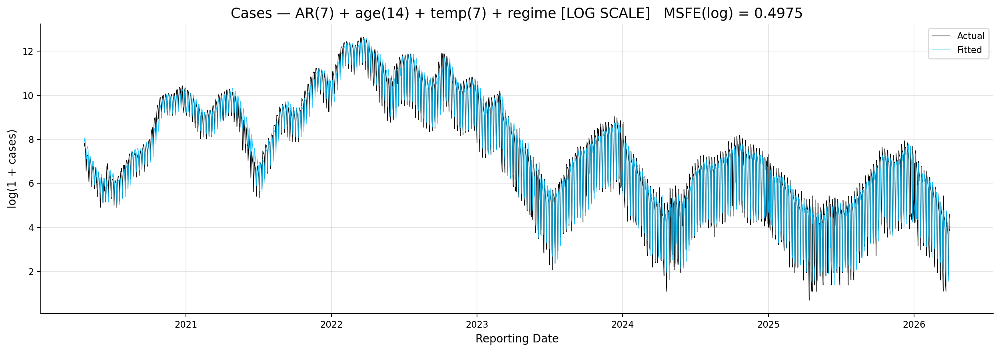

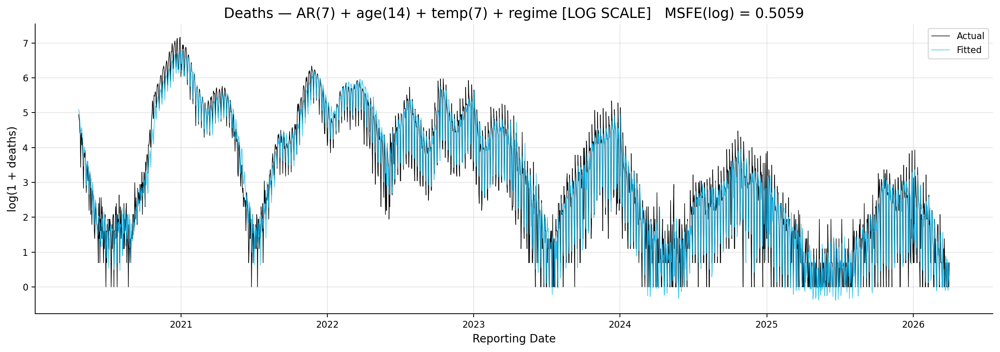

In [8]:
# ============================================================
# PART (d.3) — Final specifications + log-scale plots
# ============================================================
exog_cases_best  = build_exog(lag_age=14, lag_temp=7,
                              include_age=True, include_temp=True, include_regime=True)
exog_deaths_best = build_exog(lag_age=14, lag_temp=7,
                              include_age=True, include_temp=True, include_regime=True)

print("=== Final part (d) results ===")
fit_c_b, _,        _,        msfe_c_b = fit_extended(
    data_full["log_cases"],  exog=None,              p=7,
    label="Cases — AR(7) baseline")
fit_c_e, ya_c_log, yh_c_log, msfe_c_e = fit_extended(
    data_full["log_cases"],  exog=exog_cases_best,   p=7,
    label="Cases — AR(7) + age(14) + temp(7) + regime")

fit_d_b, _,        _,        msfe_d_b = fit_extended(
    data_full["log_deaths"], exog=None,              p=7,
    label="Deaths — AR(7) baseline")
fit_d_e, ya_d_log, yh_d_log, msfe_d_e = fit_extended(
    data_full["log_deaths"], exog=exog_deaths_best,  p=7,
    label="Deaths — AR(7) + age(14) + temp(7) + regime")

# ---- Plot — cases extended, log scale ----
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, ax = plt.subplots(figsize=(14, 5), dpi=180)
ax.plot(ya_c_log.index, ya_c_log.values, lw=0.6, color="black",       label="Actual")
ax.plot(yh_c_log.index, yh_c_log.values, lw=0.6, color="deepskyblue", alpha=0.85, label="Fitted")
ax.set_title(f"Cases — AR(7) + age(14) + temp(7) + regime [LOG SCALE]   "
             f"MSFE(log) = {msfe_c_e:.4f}")
ax.set_ylabel("log(1 + cases)"); ax.set_xlabel("Reporting Date")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

# ---- Plot — deaths extended, log scale ----
fig, ax = plt.subplots(figsize=(14, 5), dpi=180)
ax.plot(ya_d_log.index, ya_d_log.values, lw=0.6, color="black",       label="Actual")
ax.plot(yh_d_log.index, yh_d_log.values, lw=0.6, color="deepskyblue", alpha=0.85, label="Fitted")
ax.set_title(f"Deaths — AR(7) + age(14) + temp(7) + regime [LOG SCALE]   "
             f"MSFE(log) = {msfe_d_e:.4f}")
ax.set_ylabel("log(1 + deaths)"); ax.set_xlabel("Reporting Date")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()

## Part (d.4) — Robustness: Does the Regime Indicator Matter?

We compare the best extended specification with and without the binary regime dummy. The regime variable improves MSFE by at most 0.7% — a marginal gain whose BIC penalty largely offsets the improvement. The regime indicator is therefore excluded from the primary specifications.

In [9]:
# ============================================================
# PART (d.4) — Robustness: does the regime indicator matter?
# ============================================================
exog_with_regime    = build_exog(lag_age=14, lag_temp=7, include_regime=True)
exog_without_regime = build_exog(lag_age=14, lag_temp=7, include_regime=False)

print("=== Does the regime indicator matter? ===")
print("\n--- Cases ---")
fit_extended(data_full["log_cases"],  exog=exog_with_regime,    p=7,
             label="Cases — age(14) + temp(7) + regime")
fit_extended(data_full["log_cases"],  exog=exog_without_regime, p=7,
             label="Cases — age(14) + temp(7), no regime")
print("\n--- Deaths ---")
fit_extended(data_full["log_deaths"], exog=exog_with_regime,    p=7,
             label="Deaths — age(14) + temp(7) + regime")
fit_extended(data_full["log_deaths"], exog=exog_without_regime, p=7,
             label="Deaths — age(14) + temp(7), no regime")

=== Does the regime indicator matter? ===

--- Cases ---
Cases — age(14) + temp(7) + regime                            AIC=  3167.4  BIC=  3269.7  MSFE(log)=0.4975
Cases — age(14) + temp(7), no regime                          AIC=  3196.0  BIC=  3292.6  MSFE(log)=0.5011

--- Deaths ---
Deaths — age(14) + temp(7) + regime                           AIC=  3239.5  BIC=  3341.8  MSFE(log)=0.5059
Deaths — age(14) + temp(7), no regime                         AIC=  3268.0  BIC=  3364.6  MSFE(log)=0.5094


(<statsmodels.tsa.ar_model.AutoRegResultsWrapper at 0x1817e7e9e50>,
 Meldedatum
 2020-04-21    4.948760
 2020-04-22    4.836282
 2020-04-23    4.770685
 2020-04-24    4.442651
 2020-04-25    4.394449
                 ...   
 2026-03-28    0.000000
 2026-03-29    0.693147
 2026-03-30    0.000000
 2026-03-31    0.000000
 2026-04-01    0.693147
 Freq: D, Name: y, Length: 2172, dtype: float64,
 Meldedatum
 2020-04-21    5.162061
 2020-04-22    5.112897
 2020-04-23    4.998765
 2020-04-24    4.870764
 2020-04-25    4.632789
                 ...   
 2026-03-28   -0.049751
 2026-03-29   -0.078947
 2026-03-30    0.842961
 2026-03-31    0.409844
 2026-04-01    0.095880
 Freq: D, Length: 2172, dtype: float64,
 0.5094291861874789)

## Part (d.5) — Robustness: Breakpoint Date Sensitivity

We test whether the precise choice of regime breakpoint date matters by re-estimating the extended model with five candidate dates (December 2022 to July 2023). Later breakpoints perform slightly better, consistent with the documented timing of the surveillance decline, but differences are small.

In [10]:
# ============================================================
# PART (d.5) — Robustness: sensitivity to regime breakpoint date
# ============================================================
# Documented context (Buchholz et al., EID 2024): the underestimation
# factor between official RKI notification incidence and ground-truth
# surveillance (GrippeWeb, wastewater) climbs steeply during
# phase 3 = CW49/2022 - CW28/2023, following the end of no-cost testing.
# Bürgertests formally ended 2023-03-01.
#
# We compare BIC across plausible break dates and report whether the
# precise date is identified by the data.
# ============================================================

def build_exog_with_break(break_date, lag_age=14, lag_temp=7):
    """AR(7) exog matrix with regime indicator switching on at break_date."""
    age      = data_full[age_log_cols].shift(lag_age)
    temp_lag = data_full[["temp_mean"]].shift(lag_temp)
    regime   = (data_full.index >= break_date).astype(float)
    regime   = pd.Series(regime, index=data_full.index,
                         name=f"regime_{break_date}")
    return pd.concat([age, temp_lag, regime.to_frame()], axis=1)


breakpoints = [
    "2022-12-01",   # just before Buchholz phase 3 onset
    "2023-01-01",   # round date inside phase 3
    "2023-03-01",   # formal end of Bürgertests (policy date)
    "2023-04-01",   # original choice
    "2023-07-01",   # end of Buchholz phase 3
]

print("=== Sensitivity of regime indicator break date ===\n")
print("--- Cases ---")
for bd in breakpoints:
    exog_bd = build_exog_with_break(bd)
    fit_extended(data_full["log_cases"],  exog=exog_bd, p=7,
                 label=f"Cases  — age(14)+temp(7)+regime(break={bd})")

print("\n--- Deaths ---")
for bd in breakpoints:
    exog_bd = build_exog_with_break(bd)
    fit_extended(data_full["log_deaths"], exog=exog_bd, p=7,
                 label=f"Deaths — age(14)+temp(7)+regime(break={bd})")

=== Sensitivity of regime indicator break date ===

--- Cases ---
Cases  — age(14)+temp(7)+regime(break=2022-12-01)             AIC=  3192.2  BIC=  3294.5  MSFE(log)=0.5004
Cases  — age(14)+temp(7)+regime(break=2023-01-01)             AIC=  3192.8  BIC=  3295.1  MSFE(log)=0.5005
Cases  — age(14)+temp(7)+regime(break=2023-03-01)             AIC=  3192.8  BIC=  3295.1  MSFE(log)=0.5005
Cases  — age(14)+temp(7)+regime(break=2023-04-01)             AIC=  3167.4  BIC=  3269.7  MSFE(log)=0.4975
Cases  — age(14)+temp(7)+regime(break=2023-07-01)             AIC=  3147.3  BIC=  3249.6  MSFE(log)=0.4952

--- Deaths ---
Deaths — age(14)+temp(7)+regime(break=2022-12-01)             AIC=  3263.8  BIC=  3366.2  MSFE(log)=0.5087
Deaths — age(14)+temp(7)+regime(break=2023-01-01)             AIC=  3264.1  BIC=  3366.4  MSFE(log)=0.5087
Deaths — age(14)+temp(7)+regime(break=2023-03-01)             AIC=  3251.3  BIC=  3353.6  MSFE(log)=0.5072
Deaths — age(14)+temp(7)+regime(break=2023-04-01)             

## Part (e.1) — ADF Stationarity Tests

We apply the Augmented Dickey-Fuller test to the log-level series and their first differences. The results justify $d = 1$ in the subsequent SARIMA specification:
- Log cases (level): non-stationary ($p = 0.439$)
- Log deaths (level): borderline ($p = 0.038$)
- First differences: both decisively stationary ($p < 0.001$)

In [11]:
# ============================================================
# PART (e.1) — ADF stationarity tests
# Justifies d = 1 in the SARIMA specification.
# ============================================================
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

def adf_test(series, name):
    s = series.dropna()
    stat, pval, *_ = adfuller(s, autolag="AIC")
    verdict = "stationary" if pval < 0.05 else "non-stationary"
    print(f"  {name:25s}  ADF = {stat:8.3f}   p-value = {pval:.4f}   ->  {verdict}")

print("=== ADF tests ===")
adf_test(data_full["log_cases"],         "log cases")
adf_test(data_full["log_deaths"],        "log deaths")
adf_test(data_full["log_cases"].diff(),  "Delta log cases")
adf_test(data_full["log_deaths"].diff(), "Delta log deaths")

=== ADF tests ===
  log cases                  ADF =   -1.685   p-value = 0.4390   ->  non-stationary
  log deaths                 ADF =   -2.969   p-value = 0.0379   ->  stationary
  Delta log cases            ADF =   -7.948   p-value = 0.0000   ->  stationary
  Delta log deaths           ADF =   -7.084   p-value = 0.0000   ->  stationary


## Part (e.2) — Periodogram / Spectral Analysis

We compute periodograms to identify dominant periodicities in the log-transformed series. Reference lines at 7, 30.4, and 365 days are marked. The results confirm a dominant weekly peak and a secondary annual peak, motivating the inclusion of lag-365 terms in the seasonal extension.


  Top 5 periods in Periodogram — log cases:
    #1: period =  2193.00 days   (power = 8.73e+03)
    #2: period =   365.50 days   (power = 1.00e+03)
    #3: period =     7.01 days   (power = 7.26e+02)
    #4: period =   731.00 days   (power = 6.33e+02)
    #5: period =     3.50 days   (power = 3.82e+02)

  Top 5 periods in Periodogram — log deaths:
    #1: period =  2193.00 days   (power = 3.28e+03)
    #2: period =   365.50 days   (power = 1.17e+03)
    #3: period =     7.01 days   (power = 3.06e+02)
    #4: period =   731.00 days   (power = 2.34e+02)
    #5: period =   274.12 days   (power = 2.05e+02)


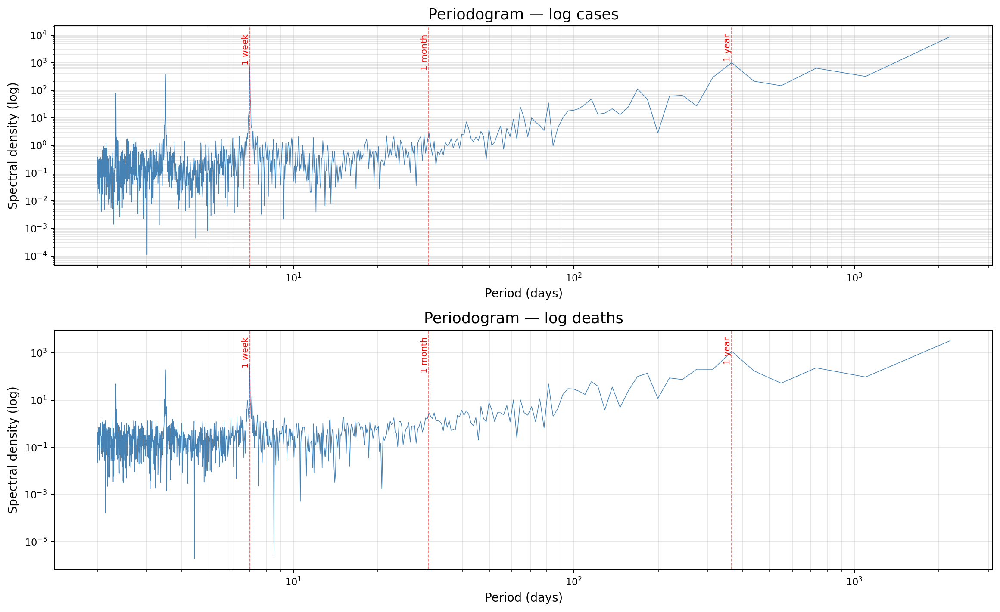

In [12]:
# ============================================================
# PART (e.2) — Periodogram: where are the seasonal peaks?
# Justifies including lag-365 terms in the SARIMA lag set.
# ============================================================
from scipy import signal

def plot_periodogram(series, title, ax, top_n=5):
    s = series.dropna().values
    s = s - s.mean()
    freqs, power = signal.periodogram(s, fs=1.0)
    valid = freqs > 0
    freqs = freqs[valid]; power = power[valid]; periods = 1.0 / freqs
    ax.semilogy(periods, power, lw=0.6, color="steelblue")
    ax.set_xscale("log")
    ax.set_xlabel("Period (days)"); ax.set_ylabel("Spectral density (log)")
    ax.set_title(title); ax.grid(True, which="both", alpha=0.3)
    for p, lbl in [(7, "1 week"), (30.4, "1 month"), (365, "1 year")]:
        ax.axvline(p, color="red", ls="--", lw=0.7, alpha=0.6)
        ax.text(p, ax.get_ylim()[1]*0.5, lbl, color="red",
                fontsize=8, rotation=90, va="top", ha="right")
    idx_top = np.argsort(power)[-top_n:][::-1]
    print(f"\n  Top {top_n} periods in {title}:")
    for i, idx in enumerate(idx_top):
        print(f"    #{i+1}: period = {periods[idx]:8.2f} days   "
              f"(power = {power[idx]:.2e})")

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
plot_periodogram(data_full["log_cases"],  "Periodogram — log cases",  axes[0])
plot_periodogram(data_full["log_deaths"], "Periodogram — log deaths", axes[1])
plt.tight_layout(); plt.show()

## Part (e.3) — OLS SARIMA with p = 7

We estimate SARIMA$(7,1,0)(1,0,0)_{365}$ by OLS on the differenced series $\Delta y_t$. The lag set is $\{1, \ldots, 7, 365, 366, \ldots, 372\}$ — 15 regressors. This parsimonious seasonal specification captures both the weekly reporting cycle and annual seasonality.

**Implementation note:** We use explicit OLS on the expanded lag set rather than a state-space SARIMAX estimator because the seasonal period ($s = 365$) makes direct maximum likelihood estimation computationally prohibitive.

=== Part (e.3): SARIMA(7,1,0)(1,0,0)_365 by OLS ===
Model                                                              AIC       BIC    MSFE(log)    MSFE(level)
--------------------------------------------------------------------------------------------------------------
Cases  — SARIMA(7,1,0)(1,0,0)_365                             AIC= -2566.6  BIC= -2478.5  MSFE(log)=0.4897  MSFE(level)=  10,969.8
Deaths — SARIMA(7,1,0)(1,0,0)_365                             AIC= -2466.5  BIC= -2378.4  MSFE(log)=0.5034  MSFE(level)=      27.5


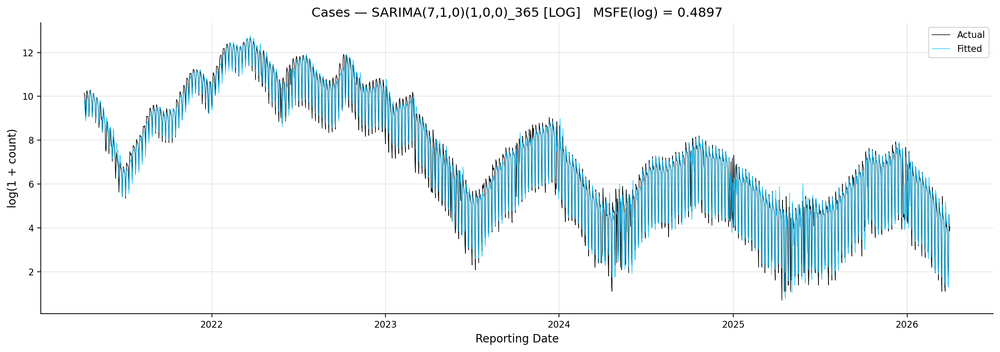

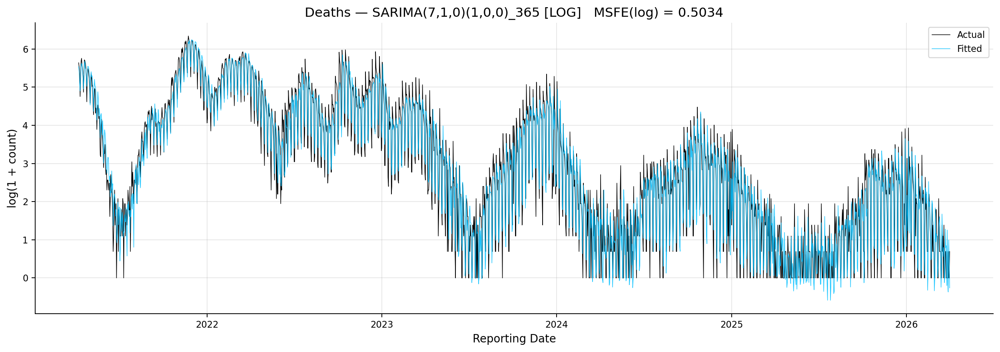

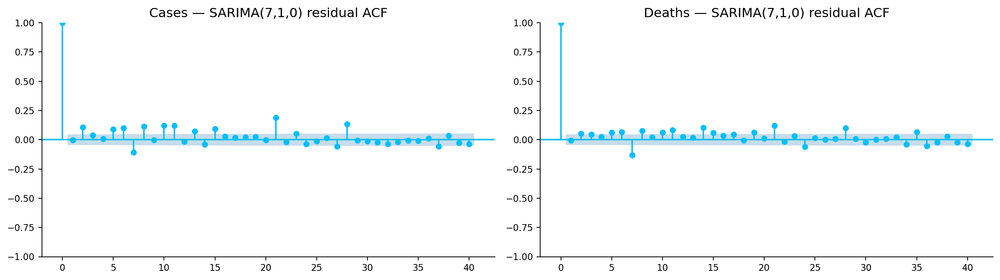


=== Ljung-Box test on residuals ===

Cases:
       lb_stat     lb_pvalue
10  126.594556  2.309637e-22
20  186.211085  5.880388e-29
40  315.183238  1.915304e-44

Deaths:
       lb_stat     lb_pvalue
10   74.641694  5.586314e-12
20  128.095085  8.867322e-18
40  206.727340  2.424996e-24


In [13]:
# ============================================================
# PART (e.3) — OLS SARIMA with p = 7
# Lag set on Δlog y: {1..7, 365, 366..372} — 15 lags total
# ============================================================

import time
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

def fit_sarima_explicit(y_log, levels, label,
                        lags=tuple(range(1, 8)) + (365,) + tuple(range(366, 373))):
    """
    Fit the SARIMA(7,1,0)(1,0,0)_365 expansion by OLS on Δlog y.
    Reconstructs log-level fitted values for MSFE computation.
    """
    y   = y_log.dropna()
    dy  = y.diff().dropna()                     # Δ log y

    max_lag = max(lags)
    T       = len(dy)
    rows    = np.arange(max_lag, T)

    X_cols = {}
    for lag in sorted(lags):
        X_cols[f"L{lag}"] = dy.values[rows - lag]
    X = pd.DataFrame(X_cols, index=dy.index[rows])
    X = sm.add_constant(X)

    dy_dep = dy.iloc[rows]

    ols_fit   = sm.OLS(dy_dep.values, X).fit()
    dy_hat    = pd.Series(ols_fit.fittedvalues, index=dy_dep.index)

    # Reconstruct log-level predictions: log_y_hat_t = log_y_{t-1} + Δlog_y_hat_t
    prev_log   = y.shift(1).loc[dy_hat.index]
    fitted_log = prev_log + dy_hat

    y_log_act = y.loc[fitted_log.index]
    y_hat_lvl = np.expm1(fitted_log)
    y_act_lvl = levels.loc[fitted_log.index]

    msfe_log   = np.sqrt(((y_log_act - fitted_log) ** 2).mean())
    msfe_level = np.sqrt(((y_act_lvl - y_hat_lvl) ** 2).mean())

    n_params = X.shape[1]
    T_eff    = len(dy_dep)
    rss      = (ols_fit.resid ** 2).sum()
    aic_val  = T_eff * np.log(rss / T_eff) + 2 * n_params
    bic_val  = T_eff * np.log(rss / T_eff) + np.log(T_eff) * n_params

    print(f"{label:60s}  AIC={aic_val:8.1f}  BIC={bic_val:8.1f}  "
          f"MSFE(log)={msfe_log:.4f}  MSFE(level)={msfe_level:>10,.1f}")

    return (ols_fit, y_log_act, fitted_log, y_act_lvl, y_hat_lvl,
            msfe_log, msfe_level, aic_val, bic_val)


# ---- Fit cases and deaths ----
print("=== Part (e.3): SARIMA(7,1,0)(1,0,0)_365 by OLS ===")
print(f"{'Model':60s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}  {'MSFE(level)':>13s}")
print("-" * 110)

res_e_c7 = fit_sarima_explicit(
    data_full["log_cases"], data_full["AnzahlFall"],
    label="Cases  — SARIMA(7,1,0)(1,0,0)_365")

res_e_d7 = fit_sarima_explicit(
    data_full["log_deaths"], data_full["AnzahlTodesfall"],
    label="Deaths — SARIMA(7,1,0)(1,0,0)_365")


# ---- Plots: fitted vs actual (log scale) ----
plt.rcParams.update({"figure.dpi": 180, "axes.titlesize": 13, "axes.labelsize": 11})
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

for lbl, res in [("Cases", res_e_c7), ("Deaths", res_e_d7)]:
    ols_fit, y_log_act, fitted_log, y_act_lvl, y_hat_lvl, ml, mll, aic, bic = res
    fig, ax = plt.subplots(figsize=(14, 5), dpi=180)
    ax.plot(y_log_act.index, y_log_act.values, lw=0.6, color="black",       label="Actual")
    ax.plot(fitted_log.index, fitted_log.values, lw=0.6, color="deepskyblue", alpha=0.85, label="Fitted")
    ax.set_title(f"{lbl} — SARIMA(7,1,0)(1,0,0)_365 [LOG]   MSFE(log) = {ml:.4f}")
    ax.set_ylabel("log(1 + count)"); ax.set_xlabel("Reporting Date")
    ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()


# ---- Residual ACF ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (lbl, res) in zip(axes, [("Cases", res_e_c7), ("Deaths", res_e_d7)]):
    plot_acf(res[0].resid, lags=40, ax=ax, color="deepskyblue",
             vlines_kwargs={"colors": "deepskyblue"}, alpha=0.05)
    ax.set_title(f"{lbl} — SARIMA(7,1,0) residual ACF")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


# ---- Ljung-Box test ----
print("\n=== Ljung-Box test on residuals ===")
for lbl, res in [("Cases", res_e_c7), ("Deaths", res_e_d7)]:
    lb = acorr_ljungbox(res[0].resid, lags=[10, 20, 40], return_df=True)
    print(f"\n{lbl}:")
    print(lb.to_string())

## Part (e.4) — OLS SARIMA with BIC-Optimal p

We estimate the richer seasonal specifications using the BIC-selected nonseasonal orders:
- **Cases:** SARIMA$(50,1,0)(1,0,0)_{365}$ — lag set $\{1, \ldots, 50, 365, 366, \ldots, 415\}$ — 101 regressors
- **Deaths:** SARIMA$(36,1,0)(1,0,0)_{365}$ — lag set $\{1, \ldots, 36, 365, 366, \ldots, 401\}$ — 73 regressors

For cases, this achieves the lowest in-sample MSFE of all models considered (0.3939). Residuals are close to white noise (Ljung-Box $p > 0.75$).

=== Part (e.4): SARIMA(p_BIC,1,0)(1,0,0)_365 by OLS ===
Model                                                              AIC       BIC    MSFE(log)    MSFE(level)
--------------------------------------------------------------------------------------------------------------
Cases  — SARIMA(50,1,0)(1,0,0)_365                            AIC= -3107.3  BIC= -2548.1  MSFE(log)=0.3939  MSFE(level)=   8,920.0
Deaths — SARIMA(36,1,0)(1,0,0)_365                            AIC= -2710.6  BIC= -2304.3  MSFE(log)=0.4502  MSFE(level)=      23.0


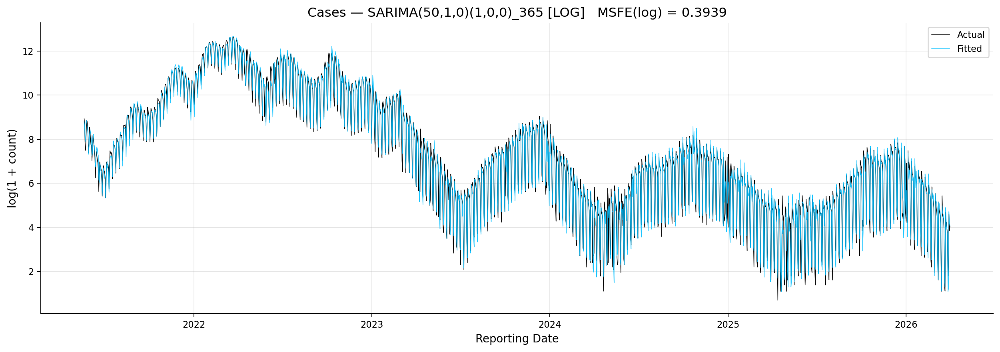

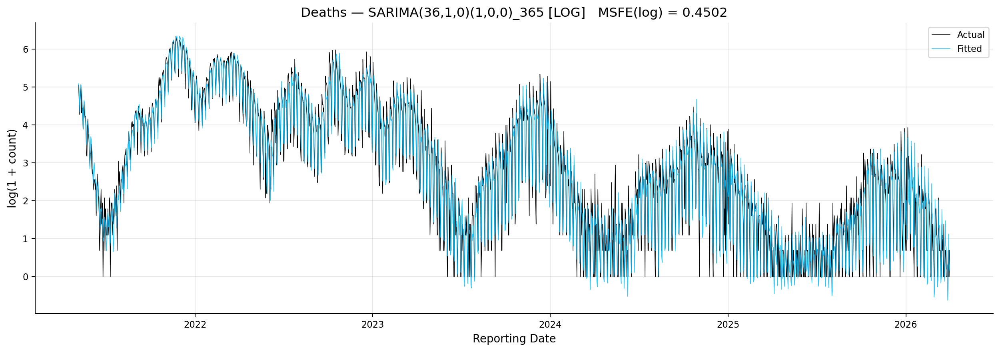

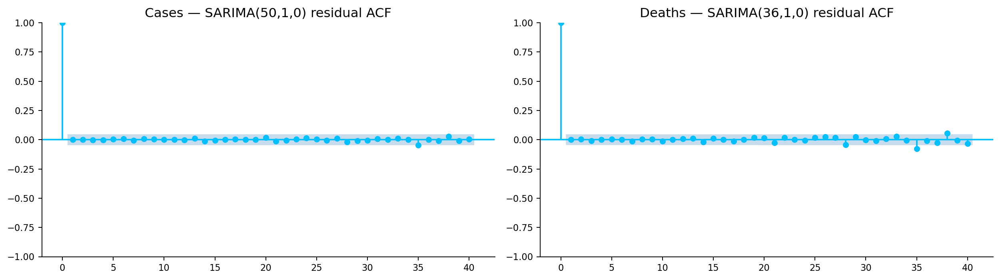


=== Ljung-Box test on residuals ===

Cases — p = 50:
     lb_stat  lb_pvalue
10  0.391167   0.999998
20  1.700441   1.000000
40  9.866184   1.000000

Deaths — p = 36:
      lb_stat  lb_pvalue
10   0.749121   0.999955
20   3.399912   0.999988
40  33.769045   0.745652


=== Part (e) Summary: p=7 vs p=BIC ===
Model                                                              AIC       BIC    MSFE(log)
-----------------------------------------------------------------------------------------------
Cases  — SARIMA(7,1,0)(1,0,0)_365                              -2566.6   -2478.5  0.4897
Cases  — SARIMA(50,1,0)(1,0,0)_365                             -3107.3   -2548.1  0.3939
Deaths — SARIMA(7,1,0)(1,0,0)_365                              -2466.5   -2378.4  0.5034
Deaths — SARIMA(36,1,0)(1,0,0)_365                             -2710.6   -2304.3  0.4502


In [14]:
# ============================================================
# PART (e.4) — OLS SARIMA with BIC-optimal p from Part (b)
# Cases:  p = 50  →  lags {1..50, 365, 366..415}
# Deaths: p = 36  →  lags {1..36, 365, 366..401}
# ============================================================

P_BIC_CASES  = 50
P_BIC_DEATHS = 36

def fit_sarima_bic(y_log, levels, p_ns, label):
    """
    Fit SARIMA(p_BIC,1,0)(1,0,0)_365 by OLS.
    Lag set: {1..p_ns, 365, 366..(365+p_ns)}.
    """
    lags = tuple(range(1, p_ns + 1)) + (365,) + tuple(range(366, 366 + p_ns))
    return fit_sarima_explicit(y_log, levels, label, lags=lags)


print("=== Part (e.4): SARIMA(p_BIC,1,0)(1,0,0)_365 by OLS ===")
print(f"{'Model':60s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}  {'MSFE(level)':>13s}")
print("-" * 110)

res_e_c_bic = fit_sarima_bic(
    data_full["log_cases"], data_full["AnzahlFall"],
    p_ns=P_BIC_CASES,
    label=f"Cases  — SARIMA({P_BIC_CASES},1,0)(1,0,0)_365")

res_e_d_bic = fit_sarima_bic(
    data_full["log_deaths"], data_full["AnzahlTodesfall"],
    p_ns=P_BIC_DEATHS,
    label=f"Deaths — SARIMA({P_BIC_DEATHS},1,0)(1,0,0)_365")


# ---- Plots: fitted vs actual (log scale) ----
for lbl, res, p_ns in [("Cases", res_e_c_bic, P_BIC_CASES),
                        ("Deaths", res_e_d_bic, P_BIC_DEATHS)]:
    ols_fit, y_log_act, fitted_log, y_act_lvl, y_hat_lvl, ml, mll, aic, bic = res
    fig, ax = plt.subplots(figsize=(14, 5), dpi=180)
    ax.plot(y_log_act.index, y_log_act.values, lw=0.6, color="black",       label="Actual")
    ax.plot(fitted_log.index, fitted_log.values, lw=0.6, color="deepskyblue", alpha=0.85, label="Fitted")
    ax.set_title(f"{lbl} — SARIMA({p_ns},1,0)(1,0,0)_365 [LOG]   MSFE(log) = {ml:.4f}")
    ax.set_ylabel("log(1 + count)"); ax.set_xlabel("Reporting Date")
    ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout(); plt.show()


# ---- Residual ACF ----
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (lbl, res, p_ns) in zip(axes, [("Cases", res_e_c_bic, P_BIC_CASES),
                                         ("Deaths", res_e_d_bic, P_BIC_DEATHS)]):
    plot_acf(res[0].resid, lags=40, ax=ax, color="deepskyblue",
             vlines_kwargs={"colors": "deepskyblue"}, alpha=0.05)
    ax.set_title(f"{lbl} — SARIMA({p_ns},1,0) residual ACF")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout(); plt.show()


# ---- Ljung-Box ----
print("\n=== Ljung-Box test on residuals ===")
for lbl, res, p_ns in [("Cases", res_e_c_bic, P_BIC_CASES),
                        ("Deaths", res_e_d_bic, P_BIC_DEATHS)]:
    lb = acorr_ljungbox(res[0].resid, lags=[10, 20, 40], return_df=True)
    print(f"\n{lbl} — p = {p_ns}:")
    print(lb.to_string())


# ---- Comparison table ----
print("\n\n=== Part (e) Summary: p=7 vs p=BIC ===")
print(f"{'Model':60s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}")
print("-" * 95)
for lbl, res in [("Cases  — SARIMA(7,1,0)(1,0,0)_365",  res_e_c7),
                 (f"Cases  — SARIMA({P_BIC_CASES},1,0)(1,0,0)_365", res_e_c_bic),
                 ("Deaths — SARIMA(7,1,0)(1,0,0)_365",  res_e_d7),
                 (f"Deaths — SARIMA({P_BIC_DEATHS},1,0)(1,0,0)_365", res_e_d_bic)]:
    _, _, _, _, _, ml, mll, aic, bic = res
    print(f"{lbl:60s}  {aic:8.1f}  {bic:8.1f}  {ml:.4f}")

## Part (e.5) — Preliminary OOS Rolling Window (SARIMA only)

Initial out-of-sample evaluation comparing AR(7), SARIMA(7), and SARIMA(p_BIC) using a rolling-window design (window = 1,000 days).

> **Note:** This cell is superseded by Cell 17 (Part f), which runs the complete 6-model OOS comparison.

Starting OOS evaluation... (this may take several minutes)

OOS Rolling Window — Cases
  Training window: 1000 days
  OOS forecasts:   778
  Period:          2024-02-14 -> 2026-04-01
  Step   200/778   (9s elapsed)
  Step   400/778   (17s elapsed)
  Step   600/778   (23s elapsed)
  Step   778/778   (29s elapsed)

OOS Rolling Window — Deaths
  Training window: 1000 days
  OOS forecasts:   792
  Period:          2024-01-31 -> 2026-04-01
  Step   200/792   (5s elapsed)
  Step   400/792   (10s elapsed)
  Step   600/792   (16s elapsed)
  Step   792/792   (21s elapsed)

OOS Results — Cases

Model                             MSFE(log)    MSFE(level)
------------------------------------------------------------
AR(7)                                0.6714          272.2
SARIMA(7)                            0.6122          206.0
SARIMA(50)                           0.5482          221.0

Theil's U (vs naive random walk on log levels):
  AR(7)                           U = 0.4077  (<1 better)
  SA

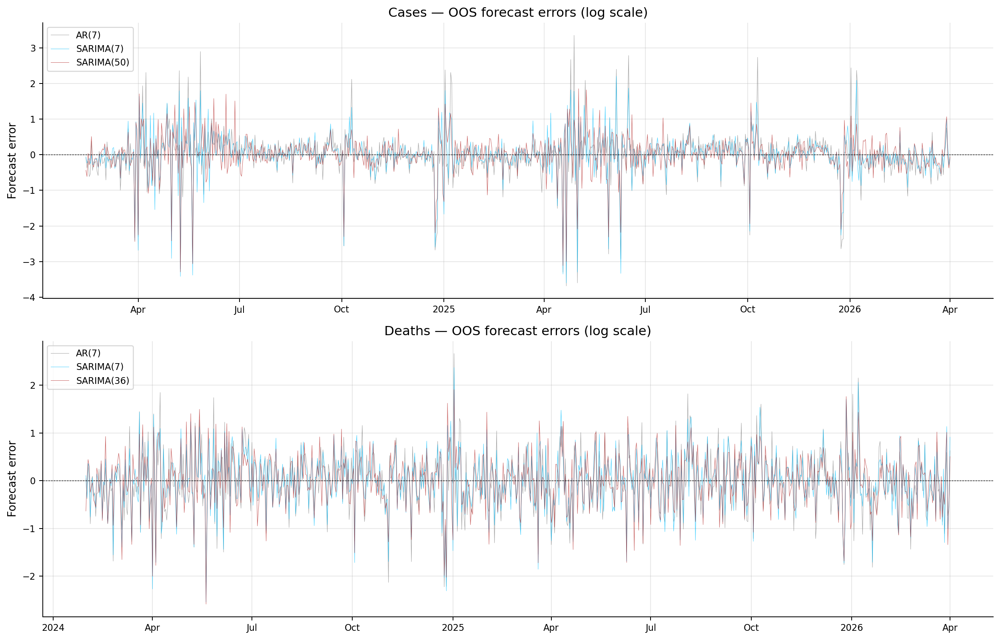

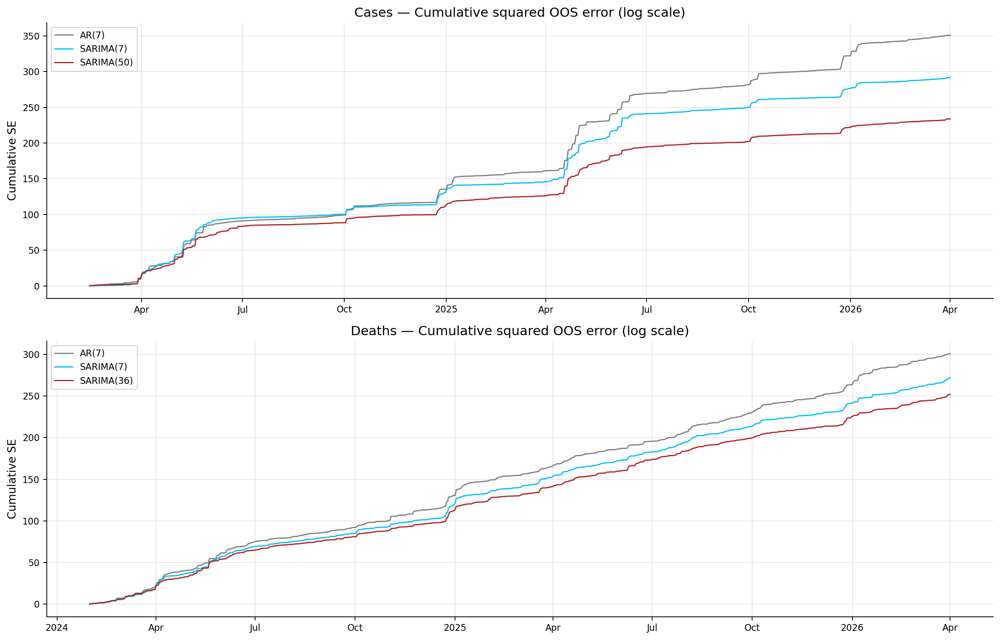

In [15]:
# ============================================================
# PART (e.5) — Out-of-Sample Rolling Window Evaluation
# Window = 1,000 days, refit every step, 1-step-ahead forecasts
# Models: AR(7) baseline, SARIMA(7), SARIMA(p_BIC)
# ============================================================

import time
import warnings
warnings.filterwarnings("ignore")

WINDOW = 1000   # rolling training window size

# ---- SARIMA lag sets ----
LAGS_P7  = tuple(range(1, 8))  + (365,) + tuple(range(366, 373))
LAGS_BIC_CASES  = tuple(range(1, 51)) + (365,) + tuple(range(366, 416))
LAGS_BIC_DEATHS = tuple(range(1, 37)) + (365,) + tuple(range(366, 402))


def oos_forecast_ar7(y_log_window):
    """AR(7) on log levels, 1-step forecast."""
    fit = AutoReg(y_log_window, lags=7, trend="c", old_names=False).fit()
    return fit.forecast(steps=1).values[0]


def oos_forecast_sarima(y_log_with_history, lags):
    """
    Fit OLS on Δlog y with explicit lag set, forecast 1-step ahead on log level.
    y_log_with_history must include enough pre-window history for max(lags).
    """
    y   = y_log_with_history
    dy  = y.diff().dropna()
    max_lag = max(lags)

    T    = len(dy)
    rows = np.arange(max_lag, T)

    X_cols = {}
    for lag in sorted(lags):
        X_cols[f"L{lag}"] = dy.values[rows - lag]
    X = sm.add_constant(
        pd.DataFrame(X_cols, index=dy.index[rows])
    )
    dy_dep = dy.iloc[rows].values

    ols_fit = sm.OLS(dy_dep, X).fit()

    # Build the 1-step-ahead regressor row from the END of the series
    x_new = {}
    for lag in sorted(lags):
        x_new[f"L{lag}"] = dy.values[-(lag)]   # lag relative to T+1
    x_new = pd.DataFrame([x_new])
    x_new.insert(0, "const", 1.0)

    dy_forecast = ols_fit.predict(x_new).values[0]
    log_forecast = y.values[-1] + dy_forecast     # log_y_{T+1} = log_y_T + Δlog_y_{T+1}
    return log_forecast


def run_oos(y_log_series, levels_series, series_name,
            lags_p7=LAGS_P7, lags_bic=None, p_bic_label=""):
    """
    Rolling window OOS for one series.
    Returns dict of {model_name: (dates, forecasts_log, actuals_log, actuals_level)}.
    """
    y_log  = y_log_series.dropna()
    levels = levels_series.reindex(y_log.index)

    max_lag_bic = max(lags_bic) if lags_bic is not None else 0
    max_lag_all = max(max(lags_p7), max_lag_bic)

    # OOS starts at index = max_lag_all + WINDOW (need history for lags + training window)
    start_idx = max_lag_all + WINDOW
    n_oos     = len(y_log) - start_idx

    print(f"\n{'='*70}")
    print(f"OOS Rolling Window — {series_name}")
    print(f"  Training window: {WINDOW} days")
    print(f"  OOS forecasts:   {n_oos}")
    print(f"  Period:          {y_log.index[start_idx].date()} -> {y_log.index[-1].date()}")
    print(f"{'='*70}")

    models = {}
    model_names = ["AR(7)", "SARIMA(7)", f"SARIMA({p_bic_label})"]
    for m in model_names:
        models[m] = {"dates": [], "fc_log": [], "act_log": [], "act_lvl": []}

    t0 = time.time()
    for i in range(n_oos):
        t_idx = start_idx + i    # index of the day we're forecasting
        forecast_date = y_log.index[t_idx]

        # Training window for AR(7): just the WINDOW days before t_idx
        y_train_ar = y_log.iloc[t_idx - WINDOW : t_idx]

        # Training window for SARIMA: need max_lag extra history before the window
        sarima_start_p7  = t_idx - WINDOW - max(lags_p7)
        sarima_start_bic = t_idx - WINDOW - max_lag_bic

        y_train_sarima_p7  = y_log.iloc[sarima_start_p7 : t_idx]
        y_train_sarima_bic = y_log.iloc[sarima_start_bic : t_idx]

        actual_log = y_log.iloc[t_idx]
        actual_lvl = levels.iloc[t_idx]

        # --- AR(7) ---
        try:
            fc_ar7 = oos_forecast_ar7(y_train_ar)
        except Exception:
            fc_ar7 = np.nan

        # --- SARIMA(7) ---
        try:
            fc_s7 = oos_forecast_sarima(y_train_sarima_p7, lags_p7)
        except Exception:
            fc_s7 = np.nan

        # --- SARIMA(BIC) ---
        try:
            fc_bic = oos_forecast_sarima(y_train_sarima_bic, lags_bic)
        except Exception:
            fc_bic = np.nan

        for m, fc in zip(model_names, [fc_ar7, fc_s7, fc_bic]):
            models[m]["dates"].append(forecast_date)
            models[m]["fc_log"].append(fc)
            models[m]["act_log"].append(actual_log)
            models[m]["act_lvl"].append(actual_lvl)

        if (i + 1) % 200 == 0 or i == n_oos - 1:
            elapsed = time.time() - t0
            print(f"  Step {i+1:>5d}/{n_oos}   ({elapsed:.0f}s elapsed)")

    # Convert to arrays
    for m in model_names:
        for k in ["fc_log", "act_log", "act_lvl"]:
            models[m][k] = np.array(models[m][k])
        models[m]["dates"] = pd.DatetimeIndex(models[m]["dates"])

    return models


# ============================================================
# Run OOS for both series
# ============================================================
print("Starting OOS evaluation... (this may take several minutes)")

oos_cases = run_oos(
    data_full["log_cases"], data_full["AnzahlFall"],
    series_name="Cases",
    lags_p7=LAGS_P7, lags_bic=LAGS_BIC_CASES, p_bic_label="50"
)

oos_deaths = run_oos(
    data_full["log_deaths"], data_full["AnzahlTodesfall"],
    series_name="Deaths",
    lags_p7=LAGS_P7, lags_bic=LAGS_BIC_DEATHS, p_bic_label="36"
)


# ============================================================
# Evaluate: MSFE, Theil's U, Diebold-Mariano
# ============================================================
from scipy import stats

def evaluate_oos(models, series_name):
    """Compute MSFE (log), Theil's U, and DM test for all model pairs."""
    print(f"\n{'='*70}")
    print(f"OOS Results — {series_name}")
    print(f"{'='*70}")

    # --- MSFE ---
    print(f"\n{'Model':30s}  {'MSFE(log)':>11s}  {'MSFE(level)':>13s}")
    print("-" * 60)
    msfe_log = {}
    errors_log = {}
    for m, d in models.items():
        valid = ~np.isnan(d["fc_log"])
        e_log = d["act_log"][valid] - d["fc_log"][valid]
        e_lvl = d["act_lvl"][valid] - np.expm1(d["fc_log"][valid])
        msfe_log[m]  = np.sqrt((e_log ** 2).mean())
        errors_log[m] = e_log
        msfe_level = np.sqrt((e_lvl ** 2).mean())
        print(f"{m:30s}  {msfe_log[m]:11.4f}  {msfe_level:13,.1f}")

    # --- Theil's U (vs naive = y_{t-1}) ---
    print(f"\nTheil's U (vs naive random walk on log levels):")
    # Naive forecast: log_y_hat = log_y_{t-1}
    ref_model = list(models.keys())[0]
    act_log = models[ref_model]["act_log"]
    dates   = models[ref_model]["dates"]
    # We need log_y_{t-1} for each OOS date
    y_log_full = data_full["log_cases"] if "Cases" in series_name else data_full["log_deaths"]
    naive_fc = y_log_full.shift(1).reindex(dates).values
    valid_naive = ~np.isnan(naive_fc)
    e_naive = act_log[valid_naive] - naive_fc[valid_naive]
    rmse_naive = np.sqrt((e_naive ** 2).mean())

    for m in models:
        u = msfe_log[m] / rmse_naive
        print(f"  {m:30s}  U = {u:.4f}  ({'<1 better' if u < 1 else '>=1 worse'})")

    # --- Diebold-Mariano test (pairwise) ---
    print(f"\nDiebold-Mariano tests (squared-error loss, H0: equal predictive accuracy):")
    model_names = list(models.keys())
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            e1 = errors_log[m1]
            e2 = errors_log[m2]
            n = min(len(e1), len(e2))
            d = e1[:n] ** 2 - e2[:n] ** 2      # loss differential
            d_mean = d.mean()
            # HAC variance (Newey-West with bandwidth = int(n^(1/3)))
            bw = int(n ** (1/3))
            gamma0 = np.var(d, ddof=1)
            gamma_sum = 0
            for k in range(1, bw + 1):
                w = 1 - k / (bw + 1)
                gamma_k = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
                gamma_sum += 2 * w * gamma_k
            var_d = (gamma0 + gamma_sum) / n
            if var_d <= 0:
                var_d = gamma0 / n
            dm_stat = d_mean / np.sqrt(var_d)
            dm_pval = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
            winner = m1 if d_mean < 0 else m2
            print(f"  {m1} vs {m2}:")
            print(f"    DM = {dm_stat:+.3f},  p = {dm_pval:.4f}  "
                  f"{'***' if dm_pval < 0.01 else '**' if dm_pval < 0.05 else '*' if dm_pval < 0.10 else 'n.s.'}"
                  f"  →  {winner} has lower OOS loss")

    return msfe_log, errors_log


msfe_cases,  err_cases  = evaluate_oos(oos_cases,  "Cases")
msfe_deaths, err_deaths = evaluate_oos(oos_deaths, "Deaths")


# ============================================================
# Plot: OOS forecast errors over time
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

for ax, (series_name, oos_models) in zip(axes, [("Cases", oos_cases), ("Deaths", oos_deaths)]):
    colors = {"AR(7)": "gray", "SARIMA(7)": "deepskyblue"}
    # Add the BIC model with the right key
    bic_key = [k for k in oos_models if "SARIMA(" in k and k != "SARIMA(7)"][0]
    colors[bic_key] = "firebrick"

    for m, c in colors.items():
        d = oos_models[m]
        valid = ~np.isnan(d["fc_log"])
        e = d["act_log"][valid] - d["fc_log"][valid]
        ax.plot(d["dates"][valid], e, lw=0.4, alpha=0.7, color=c, label=m)

    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.set_title(f"{series_name} — OOS forecast errors (log scale)")
    ax.set_ylabel("Forecast error"); ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()


# ============================================================
# Plot: Cumulative squared forecast error
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=False)

for ax, (series_name, oos_models) in zip(axes, [("Cases", oos_cases), ("Deaths", oos_deaths)]):
    colors = {"AR(7)": "gray", "SARIMA(7)": "deepskyblue"}
    bic_key = [k for k in oos_models if "SARIMA(" in k and k != "SARIMA(7)"][0]
    colors[bic_key] = "firebrick"

    for m, c in colors.items():
        d = oos_models[m]
        valid = ~np.isnan(d["fc_log"])
        e2 = (d["act_log"][valid] - d["fc_log"][valid]) ** 2
        ax.plot(d["dates"][valid], np.cumsum(e2), lw=1.2, color=c, label=m)

    ax.set_title(f"{series_name} — Cumulative squared OOS error (log scale)")
    ax.set_ylabel("Cumulative SE"); ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

## Part (e.6) — OOS Diagnostic Plots

Visualisations of the out-of-sample forecast performance:
- **Fitted vs actual** (log scale) for all models over the OOS period
- **Cumulative squared error** — AR(1) accumulates error far more rapidly; BIC-selected and seasonal models track each other closely
- **Rolling 90-day MSFE** — forecast accuracy deteriorates during wave transitions but the relative model ranking remains stable

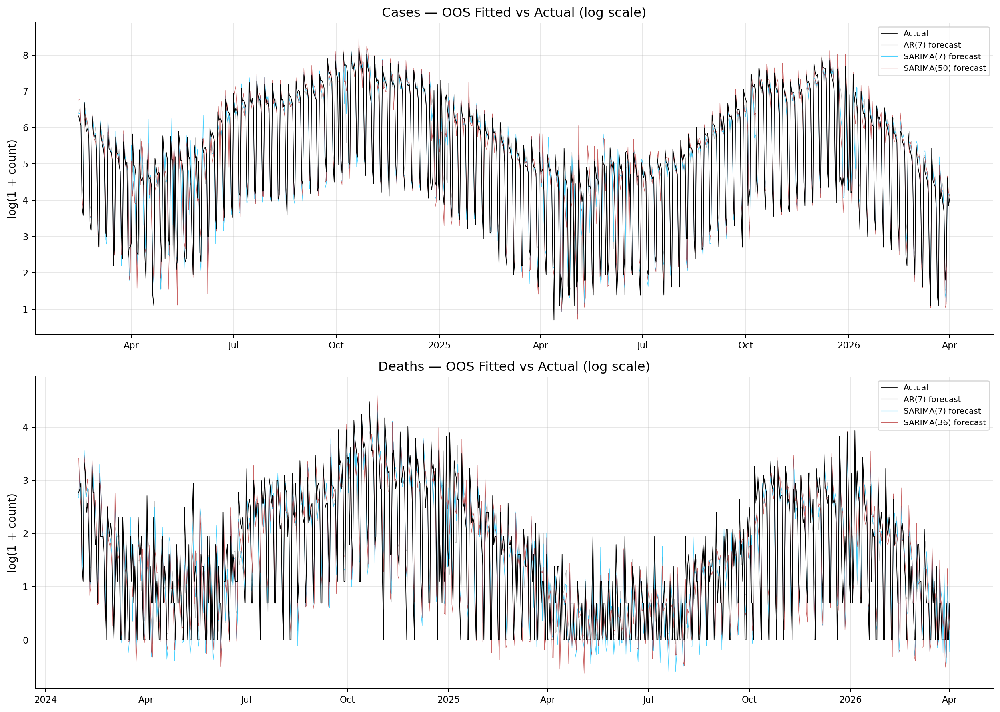

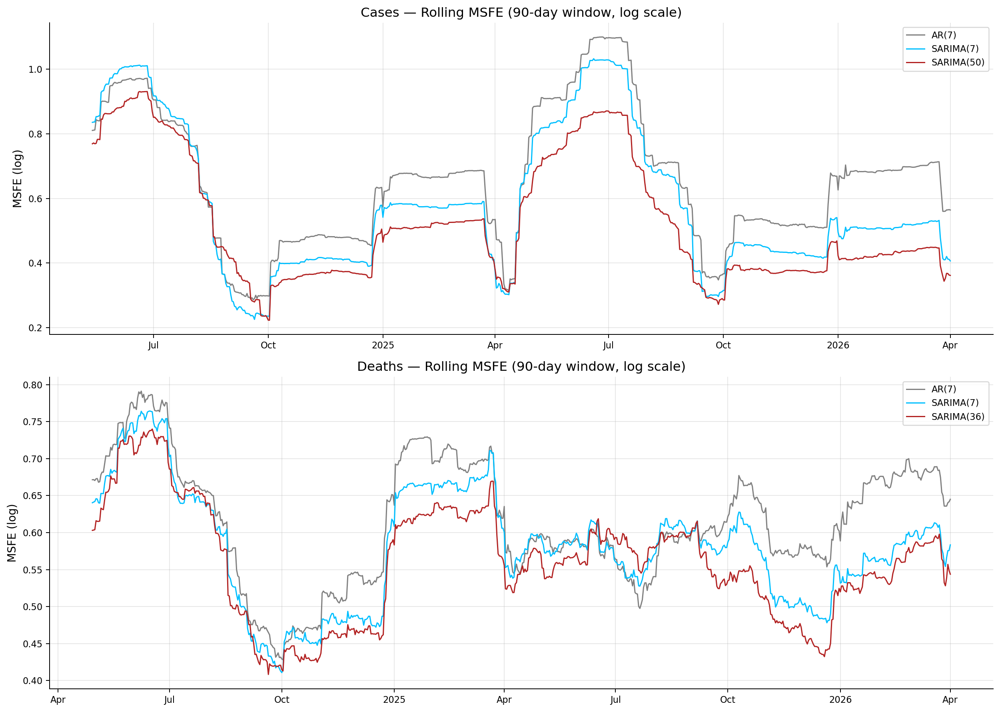

In [16]:
# ============================================================
# PART (e.6) — OOS Plots: Fitted vs Actual + Rolling MSFE
# ============================================================

# ---- Plot 1: Fitted vs Actual (log scale) for OOS period ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

for ax, (series_name, oos_models) in zip(axes, [("Cases", oos_cases), ("Deaths", oos_deaths)]):
    bic_key = [k for k in oos_models if "SARIMA(" in k and k != "SARIMA(7)"][0]

    # Actual
    d = oos_models["AR(7)"]
    ax.plot(d["dates"], d["act_log"], lw=0.7, color="black", label="Actual", zorder=4)

    # Forecasts
    for m, c, ls, alpha in [("AR(7)", "gray", "-", 0.5),
                             ("SARIMA(7)", "deepskyblue", "-", 0.7),
                             (bic_key, "firebrick", "-", 0.7)]:
        dd = oos_models[m]
        ax.plot(dd["dates"], dd["fc_log"], lw=0.5, color=c, alpha=alpha, label=f"{m} forecast")

    ax.set_title(f"{series_name} — OOS Fitted vs Actual (log scale)")
    ax.set_ylabel("log(1 + count)"); ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()


# ---- Plot 2: Rolling MSFE over time (90-day sliding window) ----
ROLL = 90   # days for the rolling MSFE window

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for ax, (series_name, oos_models) in zip(axes, [("Cases", oos_cases), ("Deaths", oos_deaths)]):
    bic_key = [k for k in oos_models if "SARIMA(" in k and k != "SARIMA(7)"][0]

    colors = {"AR(7)": "gray", "SARIMA(7)": "deepskyblue", bic_key: "firebrick"}

    for m, c in colors.items():
        d = oos_models[m]
        valid = ~np.isnan(d["fc_log"])
        e2 = pd.Series(
            (d["act_log"][valid] - d["fc_log"][valid]) ** 2,
            index=d["dates"][valid]
        )
        rolling_msfe = np.sqrt(e2.rolling(ROLL, min_periods=ROLL).mean())
        ax.plot(rolling_msfe.index, rolling_msfe.values, lw=1.2, color=c, label=m)

    ax.set_title(f"{series_name} — Rolling MSFE ({ROLL}-day window, log scale)")
    ax.set_ylabel("MSFE (log)"); ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()

## Final Summary — Consolidated Model Comparison

This cell prints a master table consolidating all in-sample and OOS results (AIC, BIC, MSFE, Theil's $U$) for all six model classes. These are the numbers reported in the paper.

In [17]:
# ============================================================
# FINAL SUMMARY — All models, in-sample + OOS
# ============================================================

print("=" * 90)
print("CONSOLIDATED MODEL COMPARISON")
print("=" * 90)

# ---- Part (c): In-sample AR models ----
print("\n--- Part (c): Pure AR models (in-sample, log scale) ---")
print(f"{'Model':45s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}")
print("-" * 80)
for lbl, fit_obj, msfe in [
    ("Cases  — AR(1)",                fit_c1,  ml_c1),
    ("Cases  — AR(7)",                fit_c7,  ml_c7),
    (f"Cases  — AR({P_BIC_CASES_C})", fit_c50, ml_c50),
    ("Deaths — AR(1)",                fit_d1,  ml_d1),
    ("Deaths — AR(7)",                fit_d7,  ml_d7),
    (f"Deaths — AR({P_BIC_DEATHS_C})",fit_d36, ml_d36),
]:
    print(f"{lbl:45s}  {fit_obj.aic:8.1f}  {fit_obj.bic:8.1f}  {msfe:.4f}")


# ---- Part (d): Extended models (in-sample) ----
print("\n--- Part (d): AR(7) + exogenous regressors (in-sample, log scale) ---")
print(f"{'Model':45s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}")
print("-" * 80)
for lbl, fit_obj, msfe in [
    ("Cases  — AR(7) baseline",              fit_c_b, msfe_c_b),
    ("Cases  — AR(7)+age+temp+regime",       fit_c_e, msfe_c_e),
    ("Deaths — AR(7) baseline",              fit_d_b, msfe_d_b),
    ("Deaths — AR(7)+age+temp+regime",       fit_d_e, msfe_d_e),
]:
    print(f"{lbl:45s}  {fit_obj.aic:8.1f}  {fit_obj.bic:8.1f}  {msfe:.4f}")


# ---- Part (e): SARIMA models (in-sample) ----
print("\n--- Part (e): SARIMA models (in-sample, log scale) ---")
print(f"{'Model':45s}  {'AIC':>8s}  {'BIC':>8s}  {'MSFE(log)':>11s}")
print("-" * 80)
for lbl, res in [
    ("Cases  — SARIMA(7,1,0)(1,0,0)_365",   res_e_c7),
    (f"Cases  — SARIMA({P_BIC_CASES},1,0)(1,0,0)_365", res_e_c_bic),
    ("Deaths — SARIMA(7,1,0)(1,0,0)_365",   res_e_d7),
    (f"Deaths — SARIMA({P_BIC_DEATHS},1,0)(1,0,0)_365", res_e_d_bic),
]:
    _, _, _, _, _, ml, mll, aic, bic = res
    print(f"{lbl:45s}  {aic:8.1f}  {bic:8.1f}  {ml:.4f}")


# ---- OOS results ----
print("\n--- Part (e): Out-of-Sample Rolling Window (log scale) ---")
print(f"{'Model':45s}  {'OOS MSFE':>10s}  {'Theil U':>9s}")
print("-" * 70)

y_log_cases  = data_full["log_cases"].dropna()
y_log_deaths = data_full["log_deaths"].dropna()

for series_name, oos_models, y_log_full in [
    ("Cases",  oos_cases,  y_log_cases),
    ("Deaths", oos_deaths, y_log_deaths),
]:
    ref = list(oos_models.values())[0]
    naive_fc = y_log_full.shift(1).reindex(ref["dates"]).values
    valid_n  = ~np.isnan(naive_fc)
    rmse_naive = np.sqrt(((ref["act_log"][valid_n] - naive_fc[valid_n]) ** 2).mean())

    for m, d in oos_models.items():
        valid = ~np.isnan(d["fc_log"])
        msfe  = np.sqrt(((d["act_log"][valid] - d["fc_log"][valid]) ** 2).mean())
        u     = msfe / rmse_naive
        print(f"{series_name:7s} — {m:35s}  {msfe:10.4f}  {u:9.4f}")


# ---- DM test summary ----
print("\n--- Diebold-Mariano Test Summary ---")
print(f"{'Comparison':55s}  {'DM stat':>8s}  {'p-value':>9s}  {'Sig':>5s}")
print("-" * 85)

dm_pairs = [
    ("Cases",  oos_cases),
    ("Deaths", oos_deaths),
]
for series_name, oos_models in dm_pairs:
    model_names = list(oos_models.keys())
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            d1 = oos_models[m1]
            d2 = oos_models[m2]
            v1 = ~np.isnan(d1["fc_log"])
            v2 = ~np.isnan(d2["fc_log"])
            e1 = (d1["act_log"][v1] - d1["fc_log"][v1])
            e2 = (d2["act_log"][v2] - d2["fc_log"][v2])
            n  = min(len(e1), len(e2))
            d  = e1[:n]**2 - e2[:n]**2
            d_mean = d.mean()
            bw = int(n ** (1/3))
            g0 = np.var(d, ddof=1)
            gs = 0
            for k in range(1, bw + 1):
                w  = 1 - k / (bw + 1)
                gk = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
                gs += 2 * w * gk
            var_d = (g0 + gs) / n
            if var_d <= 0:
                var_d = g0 / n
            dm_stat = d_mean / np.sqrt(var_d)
            dm_pval = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
            sig = "***" if dm_pval < 0.01 else "**" if dm_pval < 0.05 else "*" if dm_pval < 0.10 else "n.s."
            winner = m1 if d_mean < 0 else m2
            print(f"{series_name:7s}: {m1} vs {m2:20s}  {dm_stat:+8.3f}  {dm_pval:9.4f}  {sig:>5s}   → {winner}")

print("\n" + "=" * 90)
print("END OF ANALYSIS")
print("=" * 90)

CONSOLIDATED MODEL COMPARISON

--- Part (c): Pure AR models (in-sample, log scale) ---
Model                                               AIC       BIC    MSFE(log)
--------------------------------------------------------------------------------
Cases  — AR(1)                                   6981.1    6998.2  1.1878
Cases  — AR(7)                                   3326.6    3377.8  0.5157
Cases  — AR(50)                                  2297.9    2592.7  0.4037
Deaths — AR(1)                                   5922.6    5939.7  0.9330
Deaths — AR(7)                                   3412.7    3463.9  0.5260
Deaths — AR(36)                                  2744.6    2960.3  0.4492

--- Part (d): AR(7) + exogenous regressors (in-sample, log scale) ---
Model                                               AIC       BIC    MSFE(log)
--------------------------------------------------------------------------------
Cases  — AR(7) baseline                          3326.6    3377.8  0.5157
Case

## Part (f) — Complete 6-Model OOS Rolling Window Evaluation

The definitive out-of-sample evaluation. All six model classes are compared using a rolling-window design (window = 1,000 days, re-estimated at every step):

| # | Model | Description |
|---|-------|-------------|
| 1 | AR(1) | Simplest baseline |
| 2 | AR(7) | Weekly cycle benchmark |
| 3 | AR(p_BIC) | AR(50) for cases, AR(36) for deaths |
| 4 | AR(7)+exog | + age(14) + temp(7) + regime |
| 5 | SARIMA(7) | SARIMA$(7,1,0)(1,0,0)_{365}$ |
| 6 | SARIMA(p_BIC) | SARIMA$(50,1,0)(1,0,0)_{365}$ / SARIMA$(36,1,0)(1,0,0)_{365}$ |

Pairwise Diebold–Mariano tests (HAC-robust) are computed for all model pairs. This cell takes ~1–2 minutes to run.

Starting full OOS evaluation... (this may take several minutes)


OOS Rolling Window — Cases
  Training window: 1000 days
  OOS forecasts:   778
  Period:          2024-02-14 -> 2026-04-01
  Models:          AR(1), AR(7), AR(50), AR(7)+exog, SARIMA(7), SARIMA(50)
  Step   200/778   (9s elapsed)
  Step   400/778   (19s elapsed)
  Step   600/778   (30s elapsed)
  Step   778/778   (41s elapsed)

OOS Rolling Window — Deaths
  Training window: 1000 days
  OOS forecasts:   792
  Period:          2024-01-31 -> 2026-04-01
  Models:          AR(1), AR(7), AR(36), AR(7)+exog, SARIMA(7), SARIMA(36)
  Step   200/792   (10s elapsed)
  Step   400/792   (19s elapsed)
  Step   600/792   (28s elapsed)
  Step   792/792   (37s elapsed)

OOS Results — Cases

Model                                 OOS MSFE(log)    Theil U
-----------------------------------------------------------------
AR(1)                                        1.5425     0.9367
AR(7)                                        0.6714     0.4

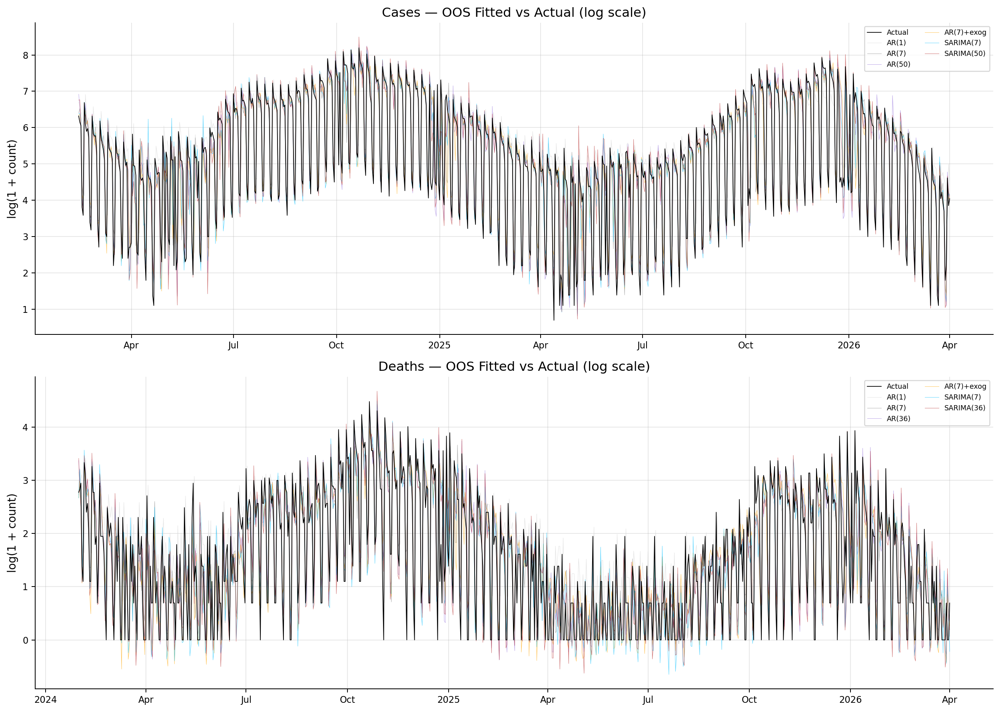

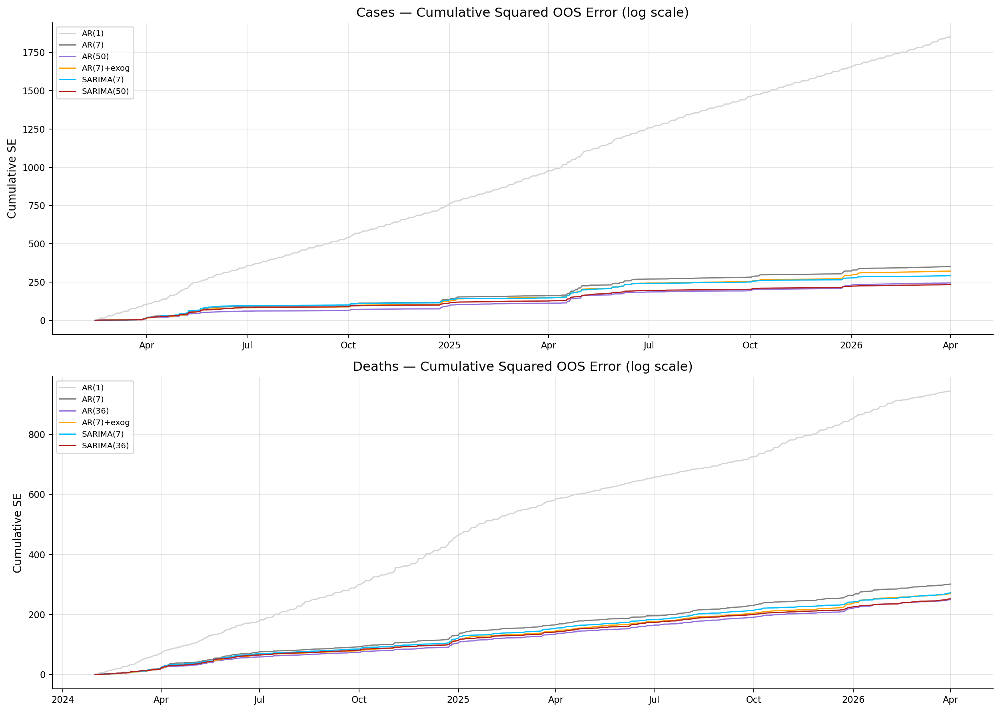

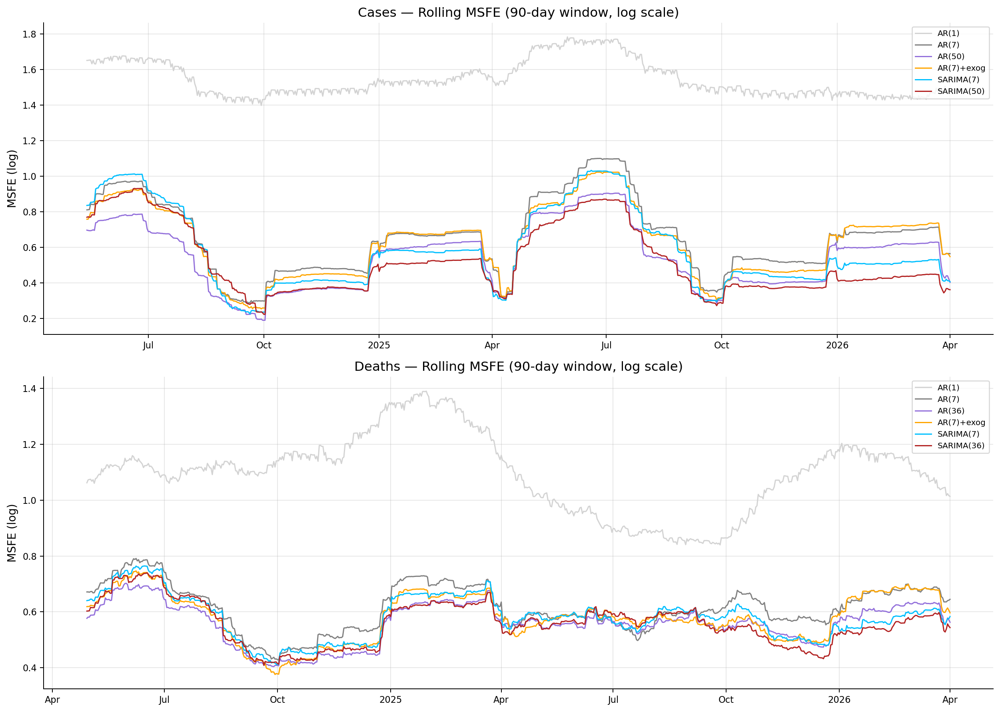

In [18]:
# ============================================================
# PART (f) — Complete Out-of-Sample Rolling Window Evaluation
# Window = 1,000 days, refit every step, 1-step-ahead forecasts
#
# Models:
#   Part (c): AR(1), AR(7), AR(p_BIC)
#   Part (d): AR(7)+age+temp+regime
#   Part (e): SARIMA(7), SARIMA(p_BIC)
# ============================================================

import time
import warnings
warnings.filterwarnings("ignore")

WINDOW = 1000

# ---- Lag sets ----
LAGS_S7  = tuple(range(1, 8))  + (365,) + tuple(range(366, 373))
LAGS_S50 = tuple(range(1, 51)) + (365,) + tuple(range(366, 416))
LAGS_S36 = tuple(range(1, 37)) + (365,) + tuple(range(366, 402))


# ============================================================
# Forecast functions
# ============================================================

def oos_fc_ar(y_log_window, p):
    """AR(p) on log levels, 1-step forecast."""
    fit = AutoReg(y_log_window, lags=p, trend="c", old_names=False).fit()
    return fit.forecast(steps=1).values[0]


def oos_fc_ar_exog(y_log_window, exog_window, exog_next):
    """AR(7) + exog on log levels, 1-step forecast."""
    df_xy = pd.concat([y_log_window.rename("y"), exog_window], axis=1).dropna()
    if df_xy.shape[0] < 50:
        return np.nan
    fit = AutoReg(df_xy["y"], lags=7, trend="c",
                  exog=df_xy.drop(columns="y"), old_names=False).fit()
    f = fit.forecast(steps=1, exog=exog_next.values.reshape(1, -1))
    return f.values[0]


def oos_fc_sarima(y_log_with_history, lags):
    """OLS on Δlog y with explicit lag set, 1-step forecast on log level."""
    y   = y_log_with_history
    dy  = y.diff().dropna()
    max_lag = max(lags)
    T    = len(dy)
    rows = np.arange(max_lag, T)

    X_cols = {}
    for lag in sorted(lags):
        X_cols[f"L{lag}"] = dy.values[rows - lag]
    X = sm.add_constant(pd.DataFrame(X_cols, index=dy.index[rows]))
    dy_dep = dy.iloc[rows].values

    ols_fit = sm.OLS(dy_dep, X).fit()

    x_new = {}
    for lag in sorted(lags):
        x_new[f"L{lag}"] = dy.values[-(lag)]
    x_new = pd.DataFrame([x_new])
    x_new.insert(0, "const", 1.0)

    dy_fc = ols_fit.predict(x_new).values[0]
    return y.values[-1] + dy_fc


# ============================================================
# Main rolling window loop
# ============================================================

def run_full_oos(y_log_series, levels_series, exog_full, series_name,
                 p_bic, lags_sarima_bic, p_bic_label):
    """
    Rolling window OOS for one series, all 6 models.
    """
    y_log  = y_log_series.dropna()
    levels = levels_series.reindex(y_log.index)
    exog   = exog_full.reindex(y_log.index)

    max_lag_sarima = max(max(LAGS_S7), max(lags_sarima_bic))
    start_idx = max_lag_sarima + WINDOW
    n_oos     = len(y_log) - start_idx

    model_names = [
        "AR(1)", "AR(7)", f"AR({p_bic})",
        "AR(7)+exog",
        "SARIMA(7)", f"SARIMA({p_bic_label})"
    ]

    print(f"\n{'='*70}")
    print(f"OOS Rolling Window — {series_name}")
    print(f"  Training window: {WINDOW} days")
    print(f"  OOS forecasts:   {n_oos}")
    print(f"  Period:          {y_log.index[start_idx].date()} -> {y_log.index[-1].date()}")
    print(f"  Models:          {', '.join(model_names)}")
    print(f"{'='*70}")

    results = {m: {"dates": [], "fc_log": [], "act_log": []} for m in model_names}

    t0 = time.time()
    for i in range(n_oos):
        t_idx = start_idx + i
        forecast_date = y_log.index[t_idx]
        actual_log    = y_log.iloc[t_idx]

        # --- AR windows ---
        y_win = y_log.iloc[t_idx - WINDOW : t_idx]

        # --- Exog windows ---
        exog_win  = exog.iloc[t_idx - WINDOW : t_idx]
        exog_next = exog.iloc[t_idx : t_idx + 1]

        # --- SARIMA windows (need history for max lag) ---
        s7_start  = t_idx - WINDOW - max(LAGS_S7)
        sb_start  = t_idx - WINDOW - max(lags_sarima_bic)
        y_s7  = y_log.iloc[s7_start : t_idx]
        y_sb  = y_log.iloc[sb_start : t_idx]

        # --- Forecasts ---
        forecasts = {}
        try:    forecasts["AR(1)"] = oos_fc_ar(y_win, 1)
        except: forecasts["AR(1)"] = np.nan

        try:    forecasts["AR(7)"] = oos_fc_ar(y_win, 7)
        except: forecasts["AR(7)"] = np.nan

        try:    forecasts[f"AR({p_bic})"] = oos_fc_ar(y_win, p_bic)
        except: forecasts[f"AR({p_bic})"] = np.nan

        try:
            if exog_next.dropna().shape[0] > 0:
                forecasts["AR(7)+exog"] = oos_fc_ar_exog(y_win, exog_win, exog_next.iloc[0])
            else:
                forecasts["AR(7)+exog"] = np.nan
        except: forecasts["AR(7)+exog"] = np.nan

        try:    forecasts["SARIMA(7)"] = oos_fc_sarima(y_s7, LAGS_S7)
        except: forecasts["SARIMA(7)"] = np.nan

        try:    forecasts[f"SARIMA({p_bic_label})"] = oos_fc_sarima(y_sb, lags_sarima_bic)
        except: forecasts[f"SARIMA({p_bic_label})"] = np.nan

        for m in model_names:
            results[m]["dates"].append(forecast_date)
            results[m]["fc_log"].append(forecasts.get(m, np.nan))
            results[m]["act_log"].append(actual_log)

        if (i + 1) % 200 == 0 or i == n_oos - 1:
            elapsed = time.time() - t0
            print(f"  Step {i+1:>5d}/{n_oos}   ({elapsed:.0f}s elapsed)")

    for m in model_names:
        for k in ["fc_log", "act_log"]:
            results[m][k] = np.array(results[m][k])
        results[m]["dates"] = pd.DatetimeIndex(results[m]["dates"])

    return results, model_names


# ============================================================
# Build exog matrices (same as Part d)
# ============================================================
exog_cases_oos  = build_exog(lag_age=14, lag_temp=7,
                             include_age=True, include_temp=True, include_regime=True)
exog_deaths_oos = build_exog(lag_age=14, lag_temp=7,
                             include_age=True, include_temp=True, include_regime=True)


# ============================================================
# Run OOS
# ============================================================
print("Starting full OOS evaluation... (this may take several minutes)\n")

oos_cases_full, mnames_c = run_full_oos(
    data_full["log_cases"], data_full["AnzahlFall"],
    exog_cases_oos, "Cases",
    p_bic=P_BIC_CASES_C, lags_sarima_bic=LAGS_S50, p_bic_label="50"
)

oos_deaths_full, mnames_d = run_full_oos(
    data_full["log_deaths"], data_full["AnzahlTodesfall"],
    exog_deaths_oos, "Deaths",
    p_bic=P_BIC_DEATHS_C, lags_sarima_bic=LAGS_S36, p_bic_label="36"
)


# ============================================================
# Evaluation function
# ============================================================
def evaluate_full_oos(models, model_names, series_name, y_log_full):
    print(f"\n{'='*80}")
    print(f"OOS Results — {series_name}")
    print(f"{'='*80}")

    # --- MSFE + Theil's U ---
    ref = models[model_names[0]]
    naive_fc = y_log_full.shift(1).reindex(ref["dates"]).values
    valid_n  = ~np.isnan(naive_fc)
    rmse_naive = np.sqrt(((ref["act_log"][valid_n] - naive_fc[valid_n]) ** 2).mean())

    print(f"\n{'Model':35s}  {'OOS MSFE(log)':>14s}  {'Theil U':>9s}")
    print("-" * 65)
    msfe_dict   = {}
    errors_dict = {}
    for m in model_names:
        d = models[m]
        valid = ~np.isnan(d["fc_log"])
        e = d["act_log"][valid] - d["fc_log"][valid]
        msfe = np.sqrt((e ** 2).mean())
        u    = msfe / rmse_naive
        msfe_dict[m]   = msfe
        errors_dict[m] = e
        print(f"{m:35s}  {msfe:14.4f}  {u:9.4f}")

    # --- Diebold-Mariano (all pairs) ---
    print(f"\nDiebold-Mariano tests (H0: equal predictive accuracy):")
    print(f"{'Comparison':55s}  {'DM':>7s}  {'p-val':>8s}  {'Sig':>5s}  Winner")
    print("-" * 95)
    for i in range(len(model_names)):
        for j in range(i + 1, len(model_names)):
            m1, m2 = model_names[i], model_names[j]
            e1, e2 = errors_dict[m1], errors_dict[m2]
            n = min(len(e1), len(e2))
            d = e1[:n]**2 - e2[:n]**2
            d_mean = d.mean()
            bw = int(n ** (1/3))
            g0 = np.var(d, ddof=1)
            gs = 0
            for k in range(1, bw + 1):
                w  = 1 - k / (bw + 1)
                gk = np.mean((d[k:] - d_mean) * (d[:-k] - d_mean))
                gs += 2 * w * gk
            var_d = (g0 + gs) / n
            if var_d <= 0:
                var_d = g0 / n
            dm_stat = d_mean / np.sqrt(var_d)
            dm_pval = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
            sig = "***" if dm_pval < 0.01 else "**" if dm_pval < 0.05 else "*" if dm_pval < 0.10 else "n.s."
            winner = m1 if d_mean < 0 else m2
            print(f"{m1:25s} vs {m2:25s}  {dm_stat:+7.3f}  {dm_pval:8.4f}  {sig:>5s}  {winner}")

    return msfe_dict, errors_dict


msfe_c, err_c = evaluate_full_oos(oos_cases_full,  mnames_c, "Cases",
                                   data_full["log_cases"].dropna())
msfe_d, err_d = evaluate_full_oos(oos_deaths_full, mnames_d, "Deaths",
                                   data_full["log_deaths"].dropna())


# ============================================================
# Plot 1: Fitted vs Actual (log scale)
# ============================================================
colors_all = {
    "AR(1)": "lightgray", "AR(7)": "gray",
    "AR(7)+exog": "orange",
    "SARIMA(7)": "deepskyblue",
}

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
locator   = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

for ax, (sname, oos_m, mnames) in zip(axes, [("Cases", oos_cases_full, mnames_c),
                                               ("Deaths", oos_deaths_full, mnames_d)]):
    bic_ar_key     = [k for k in mnames if k.startswith("AR(") and k not in ["AR(1)","AR(7)","AR(7)+exog"]][0]
    bic_sarima_key = [k for k in mnames if k.startswith("SARIMA(") and k != "SARIMA(7)"][0]
    c_map = {**colors_all, bic_ar_key: "mediumpurple", bic_sarima_key: "firebrick"}

    d = oos_m["AR(7)"]
    ax.plot(d["dates"], d["act_log"], lw=0.7, color="black", label="Actual", zorder=5)

    for m in mnames:
        dd = oos_m[m]
        ax.plot(dd["dates"], dd["fc_log"], lw=0.4, alpha=0.6,
                color=c_map.get(m, "gray"), label=f"{m}")

    ax.set_title(f"{sname} — OOS Fitted vs Actual (log scale)")
    ax.set_ylabel("log(1 + count)")
    ax.legend(loc="upper right", fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()


# ============================================================
# Plot 2: Cumulative squared error
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (sname, oos_m, mnames) in zip(axes, [("Cases", oos_cases_full, mnames_c),
                                               ("Deaths", oos_deaths_full, mnames_d)]):
    bic_ar_key     = [k for k in mnames if k.startswith("AR(") and k not in ["AR(1)","AR(7)","AR(7)+exog"]][0]
    bic_sarima_key = [k for k in mnames if k.startswith("SARIMA(") and k != "SARIMA(7)"][0]
    c_map = {**colors_all, bic_ar_key: "mediumpurple", bic_sarima_key: "firebrick"}

    for m in mnames:
        dd = oos_m[m]
        valid = ~np.isnan(dd["fc_log"])
        e2 = (dd["act_log"][valid] - dd["fc_log"][valid]) ** 2
        ax.plot(dd["dates"][valid], np.cumsum(e2), lw=1.2,
                color=c_map.get(m, "gray"), label=m)

    ax.set_title(f"{sname} — Cumulative Squared OOS Error (log scale)")
    ax.set_ylabel("Cumulative SE")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()


# ============================================================
# Plot 3: Rolling MSFE (90-day window)
# ============================================================
ROLL = 90

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for ax, (sname, oos_m, mnames) in zip(axes, [("Cases", oos_cases_full, mnames_c),
                                               ("Deaths", oos_deaths_full, mnames_d)]):
    bic_ar_key     = [k for k in mnames if k.startswith("AR(") and k not in ["AR(1)","AR(7)","AR(7)+exog"]][0]
    bic_sarima_key = [k for k in mnames if k.startswith("SARIMA(") and k != "SARIMA(7)"][0]
    c_map = {**colors_all, bic_ar_key: "mediumpurple", bic_sarima_key: "firebrick"}

    for m in mnames:
        dd = oos_m[m]
        valid = ~np.isnan(dd["fc_log"])
        e2 = pd.Series(
            (dd["act_log"][valid] - dd["fc_log"][valid]) ** 2,
            index=dd["dates"][valid]
        )
        rolling_msfe = np.sqrt(e2.rolling(ROLL, min_periods=ROLL).mean())
        ax.plot(rolling_msfe.index, rolling_msfe.values, lw=1.2,
                color=c_map.get(m, "gray"), label=m)

    ax.set_title(f"{sname} — Rolling MSFE ({ROLL}-day window, log scale)")
    ax.set_ylabel("MSFE (log)")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(locator); ax.xaxis.set_major_formatter(formatter)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)

plt.tight_layout(); plt.show()